# Wheat Futures Return Prediction — Regional Per-Region Approach

**Objective:** Predict 5-day forward returns on Milling Wheat N2 futures using per-region
agricultural data from CY-Bench, following the regional modelling methodology of
Paudel et al. (2022).

**Key Design Choices (following Paudel et al. 2022 & Thaker et al. 2024):**

1. **One model per region** — each NUTS-level region in FR, DE, PL gets its own regression
   model trained on that region's agricultural features + shared price features. This avoids
   aggregation errors that accumulate when predictors are averaged across heterogeneous
   regions (Paudel et al. 2022, Section 1).
2. **Region selection** — not all regions are informative. Adding too many regions can
   degrade performance (Thaker et al. 2024, Figure 5). We apply both forward and backward
   stepwise selection with the one-standard-error rule (MA429 Lecture 3) to select the
   most predictive subset.
3. **Production-weighted aggregation** — per-region predictions are aggregated to EU-level
   using crop-area/production weights (Paudel et al. 2022, Section 2.5.3; Cerrani &
   López Lozano, 2017).
4. **Four model families** — Ridge, Lasso, Gradient Boosted Trees, Random Forest
   (representing linear regularised, sparse linear, and two ensemble methods).
5. **Regression target** — continuous 5-day forward return (not classification).

**Period:** 2003–2023 | **Data:** Euronext Milling Wheat N2 + CY-Bench (FR, DE, PL)

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
from datetime import timedelta

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All imports successful.")

All imports successful.


---
## 1. Load and Prepare Futures Price Data

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
FUTURES_PATH = "Milling Wheat N2 Futures Historical Data.csv"
CYBENCH_DATA_DIR = "../data/raw/cybench/cybench-data/wheat"

FORECAST_HORIZON = 5   # 5 trading days (1 week) forward return
AG_LAG_DAYS = 0        # No artificial lag: futures traders react in real time

# ============================================================
# Load futures data
# ============================================================
futures_raw = pd.read_csv(FUTURES_PATH)
print(f"Raw futures data shape: {futures_raw.shape}")
futures_raw.head()

Raw futures data shape: (6938, 7)


,Date,Price,Open,High,Low,Vol.,Change %
0,02/12/2026,192.25,191.00,192.50,190.00,51.93K,0.92%
1,02/11/2026,190.50,189.75,191.50,189.75,47.70K,0.53%
2,02/10/2026,189.50,189.25,191.25,189.00,44.92K,0.00%
3,02/09/2026,189.50,189.00,190.50,188.50,46.47K,-0.26%
4,02/06/2026,190.00,193.25,193.75,189.75,65.48K,-1.81%


In [5]:
# Parse and clean futures data
futures = futures_raw.copy()
futures['Date'] = pd.to_datetime(futures['Date'], format='%m/%d/%Y')
futures = futures.sort_values('Date').reset_index(drop=True)

for col in ['Price', 'Open', 'High', 'Low']:
    futures[col] = pd.to_numeric(
        futures[col].astype(str).str.replace(',', ''), errors='coerce'
    )

def parse_volume(v):
    v = str(v).strip().replace(',', '')
    if v == '-' or v == 'nan' or v == '':
        return np.nan
    if v.upper().endswith('K'):
        return float(v[:-1]) * 1000
    if v.upper().endswith('M'):
        return float(v[:-1]) * 1_000_000
    return float(v)

futures['Volume'] = futures['Vol.'].apply(parse_volume)
futures['Change_Pct'] = pd.to_numeric(
    futures['Change %'].astype(str).str.replace('%', ''), errors='coerce'
)

futures = futures[
    (futures['Date'] >= '2002-12-31') & (futures['Date'] <= '2023-12-31')
].copy()

futures = futures[['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']]
futures['Volume'] = futures['Volume'].ffill()
futures = futures.dropna(subset=['Price']).reset_index(drop=True)

print(f"Futures data: {futures.shape[0]} trading days from "
      f"{futures['Date'].min().date()} to {futures['Date'].max().date()}")
futures.head()

Futures data: 5379 trading days from 2002-12-31 to 2023-12-29


,Date,Price,Open,High,Low,Volume,Change_Pct
0,2002-12-31,112.00,112.25,112.25,112.00,0.0,-0.22
1,2003-01-02,112.00,112.00,112.00,112.00,0.0,0.00
2,2003-01-03,112.00,112.00,112.00,112.00,0.0,0.00
3,2003-01-06,111.75,112.00,112.00,111.75,90.0,-0.22
4,2003-01-07,111.25,111.50,111.50,111.25,100.0,-0.45


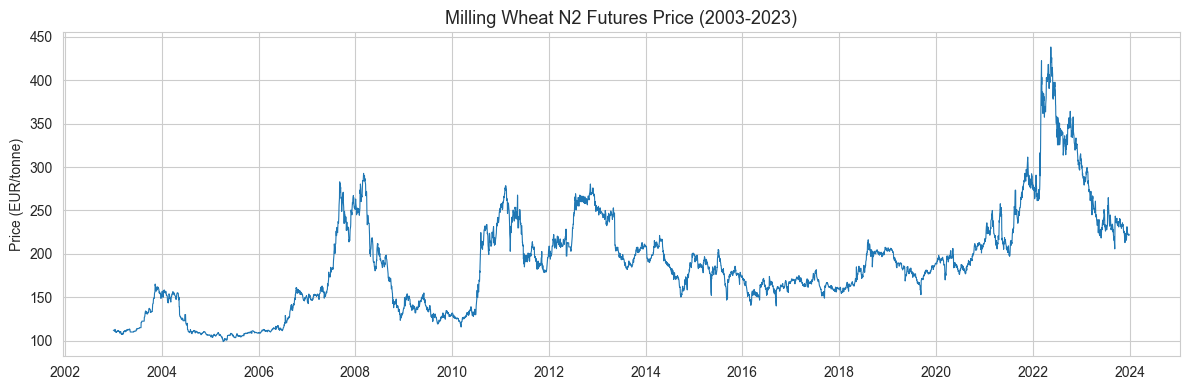

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(futures['Date'], futures['Price'], linewidth=0.8)
ax.set_title('Milling Wheat N2 Futures Price (2003-2023)', fontsize=13)
ax.set_ylabel('Price (EUR/tonne)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---
## 2. Create Target Variable and Price-Only Features

In [7]:
# ============================================================
# Target: continuous 5-day forward return (regression)
# ============================================================
futures['Fwd_Return'] = futures['Price'].shift(-FORECAST_HORIZON) / futures['Price'] - 1

# ============================================================
# MINIMAL price features: returns + volume only
#
# We deliberately strip price features to the bare minimum.
# The goal is to isolate whether AGRICULTURAL data from
# CY-Bench adds predictive signal, not to build the best
# possible price-based model. If we included RSI, SMAs,
# Bollinger bands etc., any lift from ag features could be
# confounded with price feature interactions.
#
# We keep only:
#   - ret_5d: 1-week momentum (same horizon as target)
#   - ret_20d: 1-month momentum (medium-term trend)
#   - vol_sma_ratio: relative volume (liquidity/attention)
#
# These 3 features form a minimal "market state" control.
# ============================================================

futures['ret_5d'] = futures['Price'].pct_change(5)
futures['ret_20d'] = futures['Price'].pct_change(20)
futures['vol_sma_ratio'] = futures['Volume'] / futures['Volume'].rolling(20).mean()

price_feature_cols = ['ret_5d', 'ret_20d', 'vol_sma_ratio']
print(f"Price features ({len(price_feature_cols)}): {price_feature_cols}")

Price features (3): ['ret_5d', 'ret_20d', 'vol_sma_ratio']


---
## 3. Load CY-Bench Agricultural Data (FR, DE, PL)

We load data for all three major EU wheat producers. Unlike the previous version
which aggregated regions immediately, here we **keep each region separate** —
each region will become a candidate for per-region modelling.

In [8]:
# ============================================================
# Generic CY-Bench loader for any country
# ============================================================

def load_cybench_csv(directory, pattern):
    matches = glob.glob(os.path.join(directory, pattern))
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    return df

def load_country_data(country_code, cybench_dir):
    """
    Load all CY-Bench CSVs for a given country code.
    Returns dict of DataFrames keyed by data type.
    """
    possible = [
        os.path.join(cybench_dir, country_code),
        os.path.join(cybench_dir, 'EU'),
        cybench_dir,
    ]
    data_dir = None
    for p in possible:
        if os.path.isdir(p):
            pattern = f'meteo_wheat_{country_code}.csv'
            if glob.glob(os.path.join(p, pattern)):
                data_dir = p
                break

    if data_dir is None:
        print(f"  {country_code}: Data not found, skipping.")
        return None

    print(f"  {country_code}: Loading from {data_dir}")
    datasets = {}
    for var, pat in [('meteo', f'meteo_wheat_{country_code}.csv'),
                     ('soil_moisture', f'soil_moisture_wheat_{country_code}.csv'),
                     ('ndvi', f'ndvi_wheat_{country_code}.csv'),
                     ('fpar', f'fpar_wheat_{country_code}.csv')]:
        df = load_cybench_csv(data_dir, pat)
        if df is not None:
            # Filter to country regions
            if 'adm_id' in df.columns:
                df = df[df['adm_id'].astype(str).str.startswith(country_code)].copy()
            datasets[var] = df
            print(f"    {var}: {df.shape}, {df['adm_id'].nunique()} regions")

    # Load yield data for production weights
    yield_df = load_cybench_csv(data_dir, f'yield_wheat_{country_code}.csv')
    if yield_df is not None and 'adm_id' in yield_df.columns:
        yield_df = yield_df[yield_df['adm_id'].astype(str).str.startswith(country_code)].copy()
        datasets['yield'] = yield_df
        print(f"    yield: {yield_df.shape}, {yield_df['adm_id'].nunique()} regions")

    return datasets

# Load all three countries
print("Loading CY-Bench agricultural data\n")
country_data = {}

# DK not included because yield data starts in 2006
# countries = ['FR', 'DE', 'PL', 'RO', 'BG', 'LT', 'CZ', 'ES']
# countries = ['FR', 'DE', 'PL', 'RO', 'BG']
countries = ['FR', 'DE', 'PL']

for country in countries:
    data = load_country_data(country, CYBENCH_DATA_DIR)
    if data is not None:
        country_data[country] = data
    print()

print(f"Countries loaded: {list(country_data.keys())}")
for country, data in country_data.items():
    n_regions = set()
    for k, df in data.items():
        if 'adm_id' in df.columns:
            n_regions.update(df['adm_id'].unique())
    print(f"  {country}: {len(n_regions)} unique regions, data types: {list(data.keys())}")

Loading CY-Bench agricultural data

  FR: Loading from ../data/raw/cybench/cybench-data/wheat/FR
    meteo: (814800, 11), 97 regions
    soil_moisture: (740886, 5), 97 regions
    ndvi: (97951, 4), 97 regions
    fpar: (80316, 4), 97 regions
    yield: (2571, 7), 95 regions

  DE: Loading from ../data/raw/cybench/cybench-data/wheat/DE
    meteo: (3368400, 11), 401 regions
    soil_moisture: (3055200, 5), 400 regions
    ndvi: (350540, 4), 401 regions
    fpar: (332028, 4), 401 regions
    yield: (15233, 12), 397 regions

  PL: Loading from ../data/raw/cybench/cybench-data/wheat/PL
    meteo: (142800, 11), 17 regions
    soil_moisture: (129846, 5), 17 regions
    ndvi: (16115, 4), 17 regions
    fpar: (14076, 4), 17 regions
    yield: (301, 7), 17 regions

Countries loaded: ['FR', 'DE', 'PL']
  FR: 98 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  DE: 401 unique regions, data types: ['meteo', 'soil_moisture', 'ndvi', 'fpar', 'yield']
  PL: 17 unique re

---
## 4. Process Agricultural Data: Per-Region Daily Expansion

**Critical difference from the aggregated approach:** We do NOT average across
regions. Instead, for each region we:

1. Parse the date column (YYYYMMDD string)
2. Forward-fill to daily frequency (LOCF — last observation carried forward)
3. Keep the region identifier so we can build per-region models later

This follows Paudel et al. (2022, Section 2): "Machine learning models were built
per crop and country, i.e. data for all regions within a country were pooled to
build a model for that country."

However, we go further: we build **one model per region** and then aggregate
predictions, which Chipanshi et al. (2015) showed produces better results than
aggregating predictors first (cited in Paudel et al. 2022, Section 1).

In [9]:
# ============================================================
# Step 4a: Build production weights per region
#
# Production weights serve TWO purposes:
#   1. Aggregating per-region predictions to EU level
#      (Paudel et al. 2022, Section 2.5.3)
#   2. Informing which regions matter economically
#
# We use PREVIOUS year's production to avoid look-ahead bias.
#
# HANDLING INCOMPLETE DATA (Germany):
#   Germany's CY-Bench data has:
#     - yield:        available every year
#     - harvest_area: available only every ~4 years (census)
#     - production:   entirely NaN
#   France/Poland have all three columns filled.
#
#   Solution (following user specification):
#     1. Forward-fill harvest_area within each region
#        (area changes slowly between censuses)
#     2. Compute production = yield * harvest_area
#   This is standard practice: Eurostat publishes area data
#   less frequently than yield, and interpolation/carry-forward
#   is the norm in operational systems (Cerrani & López Lozano,
#   2017).
#
# HANDLING SHORT TIME SERIES:
#   Some regions stop reporting before 2023 (e.g., France stops
#   at 2020, some German regions earlier). We use the most
#   recent available production as fallback.
# ============================================================

production_weights = {}  # {adm_id: {year: production_tonnes}}

for cc, data in country_data.items():
    if 'yield' not in data:
        continue
    ydf = data['yield'].copy()

    # Ensure columns exist
    if 'yield' not in ydf.columns:
        continue

    # --- Handle missing harvest_area and production ---
    # Check which area column exists (FR uses 'harvest_area', DE also)
    area_col = None
    for candidate in ['harvest_area', 'planted_area']:
        if candidate in ydf.columns:
            area_col = candidate
            break

    if area_col is not None:
        # Forward-fill harvest_area within each region
        # (area changes slowly; census every ~4 years for DE)
        ydf = ydf.sort_values(['adm_id', 'harvest_year'])
        ydf[area_col] = ydf.groupby('adm_id')[area_col].ffill()
        # Also backward-fill to cover years before first census
        ydf[area_col] = ydf.groupby('adm_id')[area_col].bfill()

    # Compute production where missing
    if 'production' not in ydf.columns:
        ydf['production'] = np.nan

    missing_prod = ydf['production'].isna()
    if missing_prod.any() and area_col is not None:
        ydf.loc[missing_prod, 'production'] = (
            ydf.loc[missing_prod, 'yield'] * ydf.loc[missing_prod, area_col]
        )
        n_filled = missing_prod.sum() - ydf['production'].isna().sum()
        print(f"  {cc}: Filled {n_filled} missing production values "
              f"(yield * forward-filled {area_col})")

    # Remaining NaN in production (no area data at all)
    still_missing = ydf['production'].isna().sum()
    if still_missing > 0:
        print(f"  {cc}: {still_missing} rows still missing production "
              f"(no area data available)")

    # Build the weights dictionary
    for _, row in ydf.iterrows():
        adm = row['adm_id']
        yr = row['harvest_year']
        prod = row['production']
        if pd.notna(prod) and prod > 0:
            if adm not in production_weights:
                production_weights[adm] = {}
            production_weights[adm][yr] = prod

    n_regions = len([r for r in production_weights if r.startswith(cc)])
    print(f"  {cc}: {n_regions} regions with production weights")

print(f"\nTotal regions with production weights: {len(production_weights)}")
for cc in country_data:
    cc_regions = [r for r in production_weights if r.startswith(cc)]
    if cc_regions:
        # Show year coverage
        all_years = set()
        for r in cc_regions:
            all_years.update(production_weights[r].keys())
        print(f"  {cc}: {len(cc_regions)} regions, "
              f"years {min(all_years)}-{max(all_years)}")

# Helper: get production weight for a region in a given year
# Uses previous year's production (lag 1 year to avoid look-ahead)
def get_production_weight(adm_id, year):
    if adm_id not in production_weights:
        return 0.0
    prev_year = year - 1
    if prev_year in production_weights[adm_id]:
        return production_weights[adm_id][prev_year]
    # Fallback: use nearest earlier available year
    available = sorted(production_weights[adm_id].keys())
    earlier = [y for y in available if y < year]
    if earlier:
        return production_weights[adm_id][earlier[-1]]
    # Last resort: use earliest available
    if available:
        return production_weights[adm_id][available[0]]
    return 0.0

  FR: 95 regions with production weights
  DE: Filled 15223 missing production values (yield * forward-filled harvest_area)
  DE: 10 rows still missing production (no area data available)
  DE: 396 regions with production weights
  PL: 17 regions with production weights

Total regions with production weights: 508
  FR: 95 regions, years 1989-2020
  DE: 396 regions, years 1979-2021
  PL: 17 regions, years 2003-2020


In [10]:
# ============================================================
# Step 4b: Process time-series data PER REGION
#
# For each region, we:
#   1. Parse dates
#   2. Combine all data types (meteo, soil, ndvi, fpar)
#   3. Forward-fill to daily frequency
#   4. Store as {adm_id: DataFrame}
#
# NO cross-regional aggregation at this stage.
# ============================================================

def process_region_timeseries(df, name):
    """Parse dates and identify variable columns."""
    if df is None or df.empty:
        return None
    df = df.copy()
    meta_cols = {'adm_id', 'crop_name', 'country_code', 'date',
                 'harvest_year', 'yield', 'harvest_area', 'production',
                 'sos', 'eos', 'crop_area', 'crop_area_percentage',
                 'region_area', 'geometry'}
    var_cols = [c for c in df.columns if c not in meta_cols]
    if 'date' not in df.columns:
        return None
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['date'])
    for c in var_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[['adm_id', 'date'] + var_cols], var_cols

def build_region_daily(datasets, country_code):
    """
    Build per-region daily DataFrames from CY-Bench data.
    Returns dict: {adm_id: DataFrame with date + variable columns}
    """
    # Process each data type
    processed = {}
    for dtype in ['meteo', 'soil_moisture', 'ndvi', 'fpar']:
        if dtype not in datasets:
            continue
        result = process_region_timeseries(datasets[dtype], f"{country_code}_{dtype}")
        if result is not None:
            df, var_cols = result
            # Prefix variable names with dtype
            rename = {c: f'{dtype}_{c}' for c in var_cols}
            df = df.rename(columns=rename)
            processed[dtype] = df

    if not processed:
        return {}

    # Get all regions across data types
    all_regions = set()
    for df in processed.values():
        all_regions.update(df['adm_id'].unique())

    # Build per-region combined DataFrames
    region_dfs = {}
    for region in sorted(all_regions):
        dfs_for_region = []
        for dtype, df in processed.items():
            rdf = df[df['adm_id'] == region].drop(columns=['adm_id']).copy()
            if len(rdf) == 0:
                continue
            rdf = rdf.sort_values('date')
            dfs_for_region.append(rdf)

        if not dfs_for_region:
            continue

        # Merge all data types on date
        combined = dfs_for_region[0]
        for df in dfs_for_region[1:]:
            combined = combined.merge(df, on='date', how='outer')
        combined = combined.sort_values('date')

        # Expand to daily with LOCF
        full_dates = pd.date_range(combined['date'].min(),
                                    combined['date'].max(), freq='D')
        combined = combined.set_index('date').reindex(full_dates).ffill()
        combined = combined.reset_index().rename(columns={'index': 'date'})

        region_dfs[region] = combined

    return region_dfs


# Build per-region daily data for all countries
print("Building per-region daily datasets...\n")
all_region_dfs = {}  # {adm_id: DataFrame}

for cc, data in country_data.items():
    region_dfs = build_region_daily(data, cc)
    all_region_dfs.update(region_dfs)
    print(f"  {cc}: {len(region_dfs)} regions processed")
    if region_dfs:
        sample_region = list(region_dfs.keys())[0]
        sample_df = region_dfs[sample_region]
        n_feats = len([c for c in sample_df.columns if c != 'date'])
        print(f"    Sample region {sample_region}: {sample_df.shape[0]} days, "
              f"{n_feats} features")
        print(f"    Date range: {sample_df['date'].min().date()} to "
              f"{sample_df['date'].max().date()}")

print(f"\nTotal regions across all countries: {len(all_region_dfs)}")

Building per-region daily datasets...

  FR: 97 regions processed
    Sample region FR102: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31
  DE: 401 regions processed
    Sample region DE111: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31
  PL: 17 regions processed
    Sample region PL21: 8400 days, 12 features
    Date range: 2001-01-01 to 2023-12-31

Total regions across all countries: 515


In [11]:
# ============================================================
# Save per-region daily data to CSV
#
# One CSV per region: {adm_id}_daily.csv
# Also save a summary index CSV listing all regions.
# ============================================================

REGION_DATA_DIR = "region_daily_data"
os.makedirs(REGION_DATA_DIR, exist_ok=True)

summary_rows = []
for adm_id, df in sorted(all_region_dfs.items()):
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df.to_csv(path, index=False)
    n_feats = len([c for c in df.columns if c != 'date'])
    summary_rows.append({
        'adm_id': adm_id,
        'country': adm_id[:2],
        'n_days': len(df),
        'n_features': n_feats,
        'date_min': df['date'].min().date(),
        'date_max': df['date'].max().date(),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(REGION_DATA_DIR, "_region_index.csv"), index=False)

print(f"Saved {len(summary)} region CSVs to '{REGION_DATA_DIR}/'")
print(f"Index file: {REGION_DATA_DIR}/_region_index.csv\n")
print(summary.groupby('country').agg(
    regions=('adm_id', 'count'),
    avg_days=('n_days', 'mean'),
    avg_features=('n_features', 'mean'),
).to_string())

Saved 515 region CSVs to 'region_daily_data/'
Index file: region_daily_data/_region_index.csv

         regions  avg_days  avg_features
country                                 
DE           401    8400.0     11.995012
FR            97    8400.0     12.000000
PL            17    8400.0     12.000000


In [12]:
# ============================================================
# Load pre-generated per-region daily CSVs
#
# Skips: CY-Bench loading, parsing, daily expansion, saving
# Requires: the region_daily_data/ folder from a previous run
# Only loads regions from countries in the countries list.
# ============================================================

REGION_DATA_DIR = "./region_daily_data"

# --- Load region index ---
index_path = os.path.join(REGION_DATA_DIR, "_region_index.csv")
region_index = pd.read_csv(index_path)
print(f"Found {len(region_index)} total regions in '{REGION_DATA_DIR}/'")

# --- Filter to countries list ---
region_index = region_index[region_index['country'].isin(countries)]
print(f"After filtering to {countries}: {len(region_index)} regions")

# --- Load region CSVs into all_region_dfs ---
all_region_dfs = {}
for _, row in region_index.iterrows():
    adm_id = row['adm_id']
    path = os.path.join(REGION_DATA_DIR, f"{adm_id}_daily.csv")
    df = pd.read_csv(path, parse_dates=['date'])
    all_region_dfs[adm_id] = df

print(f"Loaded {len(all_region_dfs)} regions")
print(f"countries: {region_index.groupby('country')['adm_id'].count().to_dict()}")

Found 515 total regions in './region_daily_data/'
After filtering to ['FR', 'DE', 'PL']: 515 regions
Loaded 515 regions
countries: {'DE': 401, 'FR': 97, 'PL': 17}


---
## 4c. Per-Region Feature Engineering

Following CY-Bench (Paudel et al., 2025, Section 2.2.3) recommendations:
*"time series data are aggregated in the temporal dimension to create
domain-relevant features... monthly averages of tmin, tmax, tavg, prec,
cumulative CWB... monthly maximum values for cumulative GDD, cumul prec,
cumul fPAR, cumul NDVI... number of cold days, hot days, dry days."*

We apply these feature transformations to EACH region individually before
any cross-regional aggregation. This preserves region-specific signals
(e.g., drought in Beauce vs normal conditions in Brittany) that would be
lost if we aggregated raw features first.

In [13]:
# ============================================================
# Per-region feature engineering
#
# For each region's daily DataFrame, we compute:
#   1. Rolling means and cumulative sums (30d, 60d windows)
#   2. Threshold-based stress indicators (CY-Bench: cold/hot/dry days)
#   3. NDVI/fPAR anomalies (relative to expanding DOY climatology)
#   4. Phenological phase indicators (based on month)
#   5. Cross-variable interactions (VPD stress, DTR)
#
# CY-Bench Section 2.2.3: "Following expert recommendations we create
# monthly averages... cumulative growing degree days, cumulative
# precipitation, cumulative fPAR and cumulative NDVI... number of days
# in which tmin < 0 ('cold days'), tmax > 35 ('hot days'), prec < 1mm
# ('dry days')."
# ============================================================

def engineer_region_features(df):
    """
    Apply feature engineering to a single region's daily DataFrame.
    Input: DataFrame with 'date' column and raw CY-Bench variables.
    Output: DataFrame with original + engineered features.
    """
    df = df.copy().sort_values('date').set_index('date')
    month = df.index.month

    # ============================================================
    # A. PHENOLOGICAL PHASE INDICATORS
    # Binary flags for which crop phase we're in.
    # French winter wheat phenology:
    #   Sowing → Emergence: Oct-Nov
    #   Dormancy / Vernalisation: Dec-Feb
    #   Stem elongation: Mar-Apr
    #   Heading / Flowering: May
    #   Grain filling: Jun-Jul
    # ============================================================
    df['in_growing_season'] = ((month >= 10) | (month <= 7)).astype(float)
    df['phase_dormant'] = ((month >= 12) | (month <= 2)).astype(float)
    df['phase_stem_elong'] = ((month >= 3) & (month <= 4)).astype(float)
    df['phase_flowering'] = (month == 5).astype(float)
    df['phase_grain_fill'] = ((month >= 6) & (month <= 7)).astype(float)

    # ============================================================
    # B. PHASE-CONDITIONAL STRESS FEATURES
    # These only accumulate stress during vulnerable windows.
    # ============================================================

    # --- Vernalisation frost stress (Dec-Feb): days < -10°C ---
    if 'meteo_tmin' in df.columns:
        frost_mask = df['phase_dormant'] * (df['meteo_tmin'] < -10).astype(float)
        df['winterkill_risk_30d'] = frost_mask.rolling(30, min_periods=5).sum()
        df['winterkill_risk_60d'] = frost_mask.rolling(60, min_periods=5).sum()
        # Milder frost days (< -5°C) during dormancy
        mild_frost = df['phase_dormant'] * (df['meteo_tmin'] < -5).astype(float)
        df['frost_days_dormant_60d'] = mild_frost.rolling(60, min_periods=5).sum()

    # --- Spring heat shock (Mar-May): days > 25°C ---
    if 'meteo_tmax' in df.columns:
        spring_heat = ((month >= 3) & (month <= 5)).astype(float) * (df['meteo_tmax'] > 25).astype(float)
        df['spring_heat_days_30d'] = spring_heat.rolling(30, min_periods=5).sum()
        df['spring_heat_days_60d'] = spring_heat.rolling(60, min_periods=5).sum()

    # --- Grain-fill heat stress (May-Jul): days > 30°C ---
    # Schlenker & Roberts (2009): nonlinear temperature effects
    # indicate severe damages to US crop yields
    if 'meteo_tmax' in df.columns:
        gf_heat = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] > 30).astype(float)
        df['grainfill_heat_days_30d'] = gf_heat.rolling(30, min_periods=5).sum()
        # Cumulative excess heat above 30°C during grain fill
        gf_excess = ((month >= 5) & (month <= 7)).astype(float) * (df['meteo_tmax'] - 30).clip(lower=0)
        df['grainfill_excess_heat_30d'] = gf_excess.rolling(30, min_periods=5).sum()

    # --- CY-Bench threshold indicators (Paudel et al. 2025, §2.2.3) ---
    # "number of days tmin < 0°C ('cold days'), tmax > 35°C ('hot days'),
    #  prec < 1mm ('dry days')"
    if 'meteo_tmin' in df.columns:
        df['cold_days_30d'] = (df['meteo_tmin'] < 0).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_tmax' in df.columns:
        df['hot_days_30d'] = (df['meteo_tmax'] > 35).astype(float).rolling(30, min_periods=5).sum()
    if 'meteo_prec' in df.columns:
        df['dry_days_30d'] = (df['meteo_prec'] < 1).astype(float).rolling(30, min_periods=5).sum()

    # --- Flowering drought (Apr-Jun): cumul water deficit ---
    if 'meteo_cwb' in df.columns:
        flower_cwb = df['meteo_cwb'].copy()
        flower_cwb[~((month >= 4) & (month <= 6))] = 0
        df['flowering_drought_60d'] = flower_cwb.rolling(60, min_periods=5).sum()
        df['flowering_drought_90d'] = flower_cwb.rolling(90, min_periods=5).sum()

    # ============================================================
    # C. NDVI ANOMALY - "crop health surprise"
    # How does current NDVI compare to what's normal for this
    # time of year? Low NDVI in Jan = normal (dormant).
    # Low NDVI in May = disaster. We compute the anomaly
    # relative to the historical day-of-year mean.
    # Expanding climatology avoids future leakage.
    # ============================================================
    if 'ndvi_ndvi' in df.columns:
        df['doy'] = df.index.dayofyear
        ndvi_clim = df.groupby('doy')['ndvi_ndvi'].expanding().mean()
        ndvi_clim = ndvi_clim.reset_index(level=0, drop=True).sort_index()
        df['ndvi_anomaly'] = df['ndvi_ndvi'] - ndvi_clim
        df['ndvi_anomaly_30d'] = df['ndvi_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['doy'])

    if 'fpar_fpar' in df.columns:
        df['fpar_doy'] = df.index.dayofyear
        fpar_clim = df.groupby('fpar_doy')['fpar_fpar'].expanding().mean()
        fpar_clim = fpar_clim.reset_index(level=0, drop=True).sort_index()
        df['fpar_anomaly'] = df['fpar_fpar'] - fpar_clim
        df['fpar_anomaly_30d'] = df['fpar_anomaly'].rolling(30, min_periods=5).mean()
        df = df.drop(columns=['fpar_doy'])

    # ============================================================
    # D. COMPACT ROLLING FEATURES
    # 30 and 60-day windows on key variables.
    # CY-Bench (Paudel et al. 2025, §2.2.3): "monthly averages of
    # tmin, tmax, tavg, prec, cumulative CWB... cumulative GDD,
    # cumulative precipitation, cumulative fPAR, cumulative NDVI"
    # ============================================================
    key_vars = [v for v in ['meteo_tavg', 'meteo_tmin', 'meteo_tmax',
                            'meteo_prec', 'meteo_vpd', 'meteo_cwb',
                            'soil_moisture_ssm', 'ndvi_ndvi', 'fpar_fpar']
                if v in df.columns]
    for window in [30, 60]:
        for var in key_vars:
            df[f'{var}_mean_{window}d'] = df[var].rolling(window, min_periods=10).mean()

    # Cumulative precipitation
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            df[f'cumul_prec_{window}d'] = df['meteo_prec'].rolling(window, min_periods=10).sum()

    # Growing degree days (base 0°C)
    if 'meteo_tavg' in df.columns:
        gdd_daily = df['meteo_tavg'].clip(lower=0)
        for window in [30, 60]:
            df[f'gdd_cumul_{window}d'] = gdd_daily.rolling(window, min_periods=10).sum()

    # ============================================================
    # E. WEEKEND WEATHER ACCUMULATOR
    # Futures don't trade Sat/Sun but weather happens. On Monday,
    # the market reacts to 3 days of news (Fri evening + weekend).
    # ============================================================
    df['is_monday'] = (df.index.dayofweek == 0).astype(float)
    if 'meteo_prec' in df.columns:
        df['weekend_prec'] = df['meteo_prec'].rolling(3, min_periods=1).sum() * df['is_monday']
    if 'meteo_tmax' in df.columns:
        df['weekend_tmax'] = df['meteo_tmax'].rolling(3, min_periods=1).max() * df['is_monday']
    if 'meteo_tmin' in df.columns:
        df['weekend_tmin'] = df['meteo_tmin'].rolling(3, min_periods=1).min() * df['is_monday']

    # ============================================================
    # F. STANDARDISED PRECIPITATION INDEX (SPI-like)
    # Z-score of rolling precipitation relative to its expanding
    # historical distribution. Positive = wetter than normal,
    # negative = drought.
    # (McKee et al., 1993; widely used in drought monitoring)
    # ============================================================
    if 'meteo_prec' in df.columns:
        for window in [30, 60]:
            roll_prec = df['meteo_prec'].rolling(window, min_periods=10).sum()
            spi_mean = roll_prec.expanding(min_periods=60).mean()
            spi_std = roll_prec.expanding(min_periods=60).std()
            df[f'spi_{window}d'] = (roll_prec - spi_mean) / spi_std.replace(0, np.nan)

    # ============================================================
    # G. DIURNAL TEMPERATURE RANGE (DTR)
    # Large DTR indicates clear skies (drought risk); small DTR
    # indicates cloud cover (rain). Used in crop-climate studies.
    # (Lobell, 2007; Laudien et al., 2023)
    # ============================================================
    if 'meteo_tmax' in df.columns and 'meteo_tmin' in df.columns:
        df['dtr'] = df['meteo_tmax'] - df['meteo_tmin']
        df['dtr_mean_30d'] = df['dtr'].rolling(30, min_periods=10).mean()
        df['dtr_anomaly_30d'] = df['dtr'] - df['dtr'].expanding(min_periods=60).mean()

    # ============================================================
    # H. VPD-BASED DROUGHT STRESS INDEX
    # Vapour pressure deficit is a stronger predictor of crop
    # stress than temperature alone. High VPD = plant stomata
    # close = photosynthesis stops = yield loss.
    # (Lobell et al., 2014; Schlenker & Roberts, 2009)
    # ============================================================
    if 'meteo_vpd' in df.columns:
        vpd_critical = df['meteo_vpd'].copy()
        vpd_critical[~((month >= 3) & (month <= 7))] = 0
        df['vpd_stress_critical_30d'] = vpd_critical.rolling(30, min_periods=5).mean()
        df['vpd_stress_critical_60d'] = vpd_critical.rolling(60, min_periods=5).mean()
        # Days with VPD > 15 hPa (high atmospheric demand)
        df['high_vpd_days_30d'] = (df['meteo_vpd'] > 15).astype(float).rolling(30, min_periods=5).sum()

    # ============================================================
    # I. SOIL MOISTURE DEFICIT INDEX (SMDI-like)
    # Z-score of soil moisture relative to expanding climatology.
    # Negative = drier than normal.
    # (Narasimhan & Srinivasan, 2005)
    # ============================================================
    for sm_var in ['soil_moisture_ssm', 'soil_moisture_rsm']:
        if sm_var in df.columns:
            sm_mean = df[sm_var].expanding(min_periods=60).mean()
            sm_std = df[sm_var].expanding(min_periods=60).std()
            df[f'{sm_var}_zscore'] = (df[sm_var] - sm_mean) / sm_std.replace(0, np.nan)
            df[f'{sm_var}_zscore_30d'] = df[f'{sm_var}_zscore'].rolling(30, min_periods=5).mean()

    # ============================================================
    # J. RADIATION USE EFFICIENCY PROXY
    # FPAR * radiation ≈ absorbed photosynthetically active
    # radiation (APAR). Proxy for biomass accumulation rate.
    # (Monteith, 1972; widely used in crop models)
    # ============================================================
    if 'fpar_fpar' in df.columns and 'meteo_rad' in df.columns:
        df['apar_proxy'] = df['fpar_fpar'] * df['meteo_rad']
        df['apar_proxy_mean_30d'] = df['apar_proxy'].rolling(30, min_periods=10).mean()
        df['apar_doy'] = df.index.dayofyear
        apar_clim = df.groupby('apar_doy')['apar_proxy'].expanding().mean()
        apar_clim = apar_clim.reset_index(level=0, drop=True).sort_index()
        df['apar_anomaly'] = df['apar_proxy'] - apar_clim
        df = df.drop(columns=['apar_doy'])

    # ============================================================
    # K. TEMPERATURE OPTIMALITY INDEX
    # Wheat grows optimally at 15-22°C. We measure how far
    # current conditions deviate from this optimum.
    # (Porter & Gawith, 1999)
    # ============================================================
    if 'meteo_tavg' in df.columns:
        opt_low, opt_high = 15, 22
        temp = df['meteo_tavg']
        df['temp_suboptimal'] = np.where(
            temp < opt_low, opt_low - temp,
            np.where(temp > opt_high, temp - opt_high, 0)
        )
        df['temp_suboptimal_30d'] = df['temp_suboptimal'].rolling(30, min_periods=10).mean()
        # During critical phases only (Mar-Jul)
        subopt_critical = df['temp_suboptimal'].copy()
        subopt_critical[~((month >= 3) & (month <= 7))] = 0
        df['temp_suboptimal_critical_60d'] = subopt_critical.rolling(60, min_periods=10).mean()

    # ============================================================
    # Clean up: drop intermediate masking columns
    # Phase indicators (dormant, stem_elong, flowering) are KEPT
    # as features — they tell the model which crop phase we're in.
    # Only is_monday is dropped (used only for weekend accumulator).
    # ============================================================
    df = df.drop(columns=['is_monday'], errors='ignore')
    df = df.reset_index()

    return df


# Apply to all regions
print("Applying feature engineering to all regions...\n")
n_before = {}
for adm_id, df in all_region_dfs.items():
    n_before[adm_id] = len([c for c in df.columns if c != 'date'])
    all_region_dfs[adm_id] = engineer_region_features(df)

# Report
sample = list(all_region_dfs.keys())[0]
n_after = len([c for c in all_region_dfs[sample].columns if c != 'date'])
print(f"Feature engineering complete for {len(all_region_dfs)} regions")
print(f"  Before: ~{n_before[sample]} features per region")
print(f"  After:  ~{n_after} features per region (+{n_after - n_before[sample]} engineered)")

Applying feature engineering to all regions...

Feature engineering complete for 515 regions
  Before: ~12 features per region
  After:  ~76 features per region (+64 engineered)


---
## 5. Agro-Climatic Clustering

**Motivation (Paudel et al. 2022, Section 4):** *"We believe grouping regions based on
agro-climatic similarities would help... machine learning models trained on data from
widely different regions have to learn spatial and temporal yield variability simultaneously.
Such models will struggle when relationships between predictors and yields are different
for different regions."*

**Approach:** We cluster regions by their long-term climate profiles using k-means
(unsupervised, Lecture 9). Each region is represented by its time-averaged agricultural
features (mean temperature, precipitation, NDVI, soil moisture over the full training period).
Regions with similar climate profiles are grouped together.

**Why cluster before modelling?**
- Reduces ~500 regions to ~5-10 clusters, each internally homogeneous
- Within-cluster aggregation cancels idiosyncratic noise while preserving
  the cluster's distinctive climate signal (same principle as bagging, Lecture 4)
- Production-weighted aggregation within clusters ensures big regions dominate
- The number of clusters k becomes a hyperparameter tuned via CV

Climate profiles computed for 515 regions
Profile features: ['meteo_tavg_mean', 'meteo_tavg_std', 'meteo_tmax_mean', 'meteo_tmax_std', 'meteo_tmin_mean', 'meteo_tmin_std', 'meteo_prec_mean', 'meteo_prec_std', 'meteo_vpd_mean', 'meteo_vpd_std', 'ndvi_ndvi_mean', 'ndvi_ndvi_std', 'soil_moisture_ssm_mean', 'soil_moisture_ssm_std']
  k=3: inertia=4458.8
  k=4: inertia=3785.1
  k=5: inertia=3174.8
  k=6: inertia=2899.0
  k=7: inertia=2680.3
  k=8: inertia=2504.3
  k=9: inertia=2333.3
  k=10: inertia=2182.4
  k=11: inertia=2047.8
  k=12: inertia=1923.9
  k=13: inertia=1846.1
  k=14: inertia=1713.2
  k=15: inertia=1653.6
  k=16: inertia=1549.4
  k=17: inertia=1484.4
  k=18: inertia=1448.1
  k=19: inertia=1396.9
  k=20: inertia=1337.4
  k=21: inertia=1279.8
  k=22: inertia=1257.4
  k=23: inertia=1232.2
  k=24: inertia=1184.5
  k=25: inertia=1173.0
  k=26: inertia=1139.6
  k=27: inertia=1123.6
  k=28: inertia=1088.8
  k=29: inertia=1055.1
  k=30: inertia=1039.3
  k=31: inertia=1021.5
  k=32: in

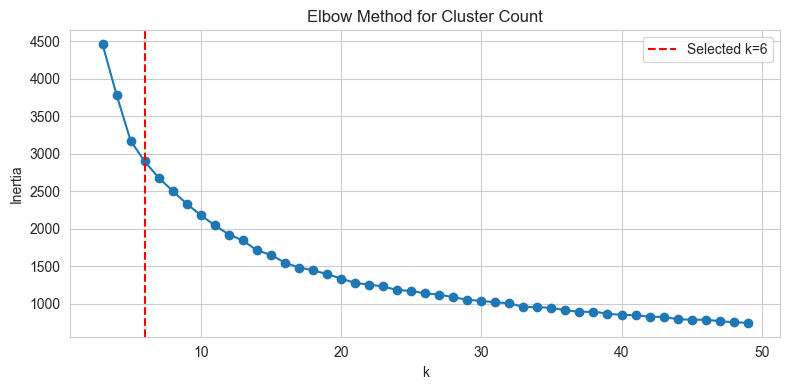


Selected k=6 (elbow method, floor=3)

Cluster composition:
  Cluster 0: 177 regions (DE:160, PL:17)
  Cluster 1: 145 regions (DE:120, FR:25)
  Cluster 2: 76 regions (DE:68, FR:8)
  Cluster 3: 3 regions (FR:3)
  Cluster 4: 40 regions (FR:40)
  Cluster 5: 74 regions (DE:53, FR:21)


In [14]:
# ============================================================
# Agro-climatic clustering of regions
#
# 1. Compute long-term climate profile per region (mean of key
#    variables over training period)
# 2. Standardise profiles
# 3. Apply k-means clustering
# 4. Aggregate features within each cluster (production-weighted)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Step 1: Compute climate profiles ---
PROFILE_VARS = ['meteo_tavg', 'meteo_tmax', 'meteo_tmin', 'meteo_prec',
                'meteo_vpd', 'ndvi_ndvi', 'soil_moisture_ssm']

profiles = {}
for adm_id, df in all_region_dfs.items():
    available = [v for v in PROFILE_VARS if v in df.columns]
    if not available:
        continue
    # Use training period only (avoid test leakage)
    train_df = df[df['date'].dt.year < 2017]
    if len(train_df) < 100:
        continue
    profile = {}
    for v in available:
        vals = train_df[v].dropna()
        if len(vals) > 0:
            profile[f'{v}_mean'] = vals.mean()
            profile[f'{v}_std'] = vals.std()
    if profile:
        profiles[adm_id] = profile

profile_df = pd.DataFrame(profiles).T
profile_df = profile_df.fillna(profile_df.median())
print(f"Climate profiles computed for {len(profile_df)} regions")
print(f"Profile features: {list(profile_df.columns)}")

# --- Step 2: Standardise and cluster ---
scaler_profile = StandardScaler()
X_profiles = scaler_profile.fit_transform(profile_df.values)

# Elbow method: plot inertia (within-cluster sum of squares) vs k.
# Pick the k where the marginal decrease in inertia slows down.
# More robust than silhouette for our purpose since we WANT granularity.

k_range = range(3, 50)
inertias = []
for k in k_range:
    if k >= len(profile_df):
        break
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_profiles)
    inertias.append((k, km.inertia_))
    print(f"  k={k}: inertia={km.inertia_:.1f}")

inertia_df = pd.DataFrame(inertias, columns=['k', 'inertia'])

# Automated elbow detection: largest drop in second derivative
diffs = np.diff(inertia_df['inertia'].values)
diffs2 = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 2  # +2 because of double diff offset
best_k = inertia_df.iloc[elbow_idx]['k']

# But enforce a floor
best_k = int(max(best_k, 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(inertia_df['k'], inertia_df['inertia'], 'o-')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Selected k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Cluster Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSelected k={best_k} (elbow method, floor=3)")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_profiles)
profile_df['cluster'] = cluster_labels

# Map region -> cluster
region_cluster = profile_df['cluster'].to_dict()

# Report cluster composition
print(f"\nCluster composition:")
for c in sorted(profile_df['cluster'].unique()):
    members = profile_df[profile_df['cluster'] == c].index.tolist()
    countries = {}
    for r in members:
        cc = r[:2]
        countries[cc] = countries.get(cc, 0) + 1
    country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
    print(f"  Cluster {c}: {len(members)} regions ({country_str})")

In [15]:
# ============================================================
# Aggregate features within each cluster (production-weighted)
#
# For each cluster, at each date:
#   weighted_mean = SUM(w_r * feature_r) / SUM(w_r)
#
# This is the same aggregation Paudel et al. (2022) use at
# the country level, but applied to agro-climatic clusters.
# ============================================================

def aggregate_cluster_features(cluster_id, region_dfs, region_cluster, ref_year=2016):
    """
    Production-weighted aggregation of features within a cluster.
    Returns a single daily DataFrame.
    """
    members = [r for r, c in region_cluster.items() if c == cluster_id and r in region_dfs]
    if not members:
        return None

    # Get all dates from all members
    all_dates = set()
    for adm_id in members:
        all_dates.update(region_dfs[adm_id]['date'].values)
    all_dates = sorted(all_dates)

    # For each date, compute weighted average
    rows = []
    # Pre-compute weights
    weights = {r: get_production_weight(r, ref_year) for r in members}
    total_w = sum(weights.values())
    if total_w == 0:
        weights = {r: 1.0 for r in members}
        total_w = len(members)

    # Get common feature columns
    feature_cols = None
    for adm_id in members:
        cols = set(c for c in region_dfs[adm_id].columns if c != 'date')
        if feature_cols is None:
            feature_cols = cols
        else:
            feature_cols = feature_cols & cols
    feature_cols = sorted(feature_cols)

    # Build indexed DataFrames for fast lookup
    indexed = {}
    for adm_id in members:
        df = region_dfs[adm_id].set_index('date')[feature_cols]
        indexed[adm_id] = df

    # Align all to common date range and compute weighted average
    date_range = pd.date_range(min(all_dates), max(all_dates), freq='D')
    result = pd.DataFrame(index=date_range, columns=feature_cols, dtype=float)
    result[:] = 0.0

    for adm_id in members:
        w = weights[adm_id] / total_w
        reindexed = indexed[adm_id].reindex(date_range).ffill().fillna(0)
        result += reindexed * w

    result = result.reset_index().rename(columns={'index': 'date'})
    return result, members


# Build cluster aggregates
print("Aggregating features within clusters...\n")
cluster_dfs = {}  # {cluster_id: DataFrame}
cluster_members = {}  # {cluster_id: [region_ids]}

for c in sorted(profile_df['cluster'].unique()):
    result = aggregate_cluster_features(c, all_region_dfs, region_cluster)
    if result is not None:
        cluster_df, members = result
        cluster_dfs[c] = cluster_df
        cluster_members[c] = members
        n_feats = len([col for col in cluster_df.columns if col != 'date'])
        print(f"  Cluster {c}: {len(members)} regions -> {cluster_df.shape[0]} days, "
              f"{n_feats} features")

print(f"\n{len(cluster_dfs)} cluster aggregates built")

Aggregating features within clusters...

  Cluster 0: 177 regions -> 8400 days, 76 features
  Cluster 1: 145 regions -> 8400 days, 68 features
  Cluster 2: 76 regions -> 8400 days, 76 features
  Cluster 3: 3 regions -> 8400 days, 76 features
  Cluster 4: 40 regions -> 8400 days, 76 features
  Cluster 5: 74 regions -> 8400 days, 76 features

6 cluster aggregates built


---
## 6. Merge and Model

We merge each cluster's aggregated features with futures data and evaluate
three approaches:

**A. Per-cluster models (Ridge, Lasso):** One model per cluster, predictions
production-weighted across clusters → EU forecast.

**B. Lasso stacking (Lecture 3 + Wolpert 1992):** Fit Ridge on each cluster
separately, then use Lasso to learn optimal combination weights. L1 penalty
drives uninformative clusters' weights to zero — implicit cluster selection.

**C. PCA regression (Lecture 10):** Stack all cluster features into one wide
matrix, apply PCA to extract EU-wide weather patterns, fit Ridge on top PCs.

In [16]:
# ============================================================
# Merge each cluster's aggregated features with futures
# ============================================================

futures_clean = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
futures_sorted = futures_clean.sort_values('Date')

cluster_model_data = {}

for c, cdf in cluster_dfs.items():
    ag_sorted = cdf.sort_values('date')

    merged = pd.merge_asof(
        futures_sorted,
        ag_sorted,
        left_on='Date',
        right_on='date',
        direction='backward'
    )
    merged = merged.drop(columns=['date'], errors='ignore')

    ag_cols = [col for col in cdf.columns if col != 'date']
    for col in ag_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)

    cluster_model_data[c] = {
        'df': merged.dropna(subset=['Fwd_Return'] + price_feature_cols).copy(),
        'ag_cols': ag_cols,
        'all_cols': price_feature_cols + ag_cols,
    }
    print(f"Cluster {c}: {merged.shape[0]} rows, "
          f"{len(ag_cols)} ag features, "
          f"{len(price_feature_cols)} price features")

Cluster 0: 5315 rows, 76 ag features, 3 price features
Cluster 1: 5315 rows, 68 ag features, 3 price features
Cluster 2: 5315 rows, 76 ag features, 3 price features
Cluster 3: 5315 rows, 76 ag features, 3 price features
Cluster 4: 5315 rows, 76 ag features, 3 price features
Cluster 5: 5315 rows, 76 ag features, 3 price features


In [17]:
# ============================================================
# Walk-forward regression (same as before, with scaler fix)
# ============================================================

def walk_forward_regression(df, feature_cols, model_class, model_kwargs,
                            test_start_year=2017, test_end_year=2023,
                            train_start_year=None, name="Model", verbose=False):
    df = df.copy()
    df['year'] = df['Date'].dt.year
    all_preds = []
    yearly_metrics = []

    for test_year in range(test_start_year, test_end_year + 1):
        train = df[df['year'] < test_year]
        if train_start_year:
            train = train[train['year'] >= train_start_year]
        test = df[df['year'] == test_year]
        if len(train) < 100 or len(test) < 20:
            continue
        train = train.dropna(subset=['Fwd_Return'])
        test = test.dropna(subset=['Fwd_Return'])
        if len(test) == 0:
            continue

        X_train = train[feature_cols].values
        y_train = train['Fwd_Return'].values
        X_test = test[feature_cols].values
        y_test = test['Fwd_Return'].values

        # Scaler fit INSIDE fold (Lecture 3: no leakage)
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        model = model_class(**model_kwargs)
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
        yearly_metrics.append({'year': test_year, 'mse': mse, 'mae': mae,
                               'r2': r2, 'dir_acc': dir_acc})
        pred_df = test[['Date', 'Fwd_Return']].copy()
        pred_df['y_pred'] = y_pred
        all_preds.append(pred_df)

    if not yearly_metrics:
        return None
    metrics_df = pd.DataFrame(yearly_metrics)
    preds_df = pd.concat(all_preds, ignore_index=True)
    overall = {
        'mse': mean_squared_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'mae': mean_absolute_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'r2': r2_score(preds_df['Fwd_Return'], preds_df['y_pred']),
        'dir_acc': np.mean(np.sign(preds_df['y_pred']) == np.sign(preds_df['Fwd_Return']))
    }
    if verbose:
        print(f"  {name}: R2={overall['r2']:.4f}, Dir={overall['dir_acc']:.4f}")
    return {'metrics_yearly': metrics_df, 'predictions': preds_df, 'overall': overall}

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_start_year = 2017
test_end_year = 2023
print(f"Test period: {test_start_year}-{test_end_year}")

Test period: 2017-2023


In [18]:
# ============================================================
# APPROACH A: Per-cluster models, production-weighted aggregation
#
# Fit Ridge and Lasso on each cluster's aggregated features.
# Aggregate cluster predictions to EU level using total cluster
# production as weight.
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor, BaggingRegressor, AdaBoostRegressor, StackingRegressor

print("="*60)
print("APPROACH A: Per-cluster models (Ridge, Lasso)")
print("="*60)

approach_a_results = {}

for model_name, (model_cls, model_kw) in [
    ('Ridge', (Ridge, {'alpha': 1.0})),
    ('Lasso', (Lasso, {'alpha': 0.001, 'max_iter': 10000})),
    ('ElasticNet', (ElasticNet, {'alpha': 0.001, 'l1_ratio': 0.5, 'max_iter': 10000})),
    ('DecisionTree', (DecisionTreeRegressor, {'max_depth': 5, 'min_samples_leaf': 30, 'random_state': 42})),
    ('KNN', (KNeighborsRegressor, {'n_neighbors': 20, 'weights': 'distance'})),
    
    # ExtraTrees: even MORE randomisation than RF.
    # RF picks the best split from a random feature subset.
    # ExtraTrees picks a RANDOM split threshold too.
    # This further decorrelates trees → more variance reduction.
    # (Geurts et al., 2006)
    ('ExtraTrees', (ExtraTreesRegressor, {
    'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
    'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    })),
    
    # BaggingRidge: Bagging (Lecture 4) with Ridge as base estimator.
    # Instead of averaging 500 trees, average 500 Ridge regressions
    # each trained on a bootstrap sample. Combines Ridge's stability
    # with bagging's variance reduction.
    ('BaggingRidge', (BaggingRegressor, {
    'estimator': Ridge(alpha=1.0),
    'n_estimators': 200, 'max_samples': 0.8, 'max_features': 0.8,
    'random_state': 42, 'n_jobs': -1
    })),
    ('BaggingLasso', (BaggingRegressor, {
    'estimator': Lasso(alpha=0.001, max_iter=10000),
    'n_estimators': 200, 'max_samples': 0.8, 'max_features': 0.8,
    'random_state': 42, 'n_jobs': -1
    })),
    ('RF', (RandomForestRegressor, {
        'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 20,
        'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1
    }))]:
    print(f"\n--- {model_name} ---")
    cluster_preds = {}

    for c in sorted(cluster_model_data.keys()):
        cdata = cluster_model_data[c]
        result = walk_forward_regression(
            df=cdata['df'], feature_cols=cdata['all_cols'],
            model_class=model_cls, model_kwargs=model_kw,
            test_start_year=test_start_year, test_end_year=test_end_year,
            name=f"Cluster {c}", verbose=True
        )
        if result is not None:
            cluster_preds[c] = result

    # Aggregate across clusters (production-weighted)
    if cluster_preds:
        all_pred_dfs = []
        for c, res in cluster_preds.items():
            pdf = res['predictions'].copy()
            # Weight = total production of cluster members
            total_prod = sum(
                get_production_weight(r, 2016) for r in cluster_members.get(c, [])
            )
            pdf['weight'] = total_prod
            pdf['cluster'] = c
            all_pred_dfs.append(pdf)

        combined = pd.concat(all_pred_dfs)
        agg = combined.groupby('Date').apply(
            lambda g: pd.Series({
                'Fwd_Return': g['Fwd_Return'].iloc[0],
                'y_pred': np.average(g['y_pred'], weights=g['weight'])
                    if g['weight'].sum() > 0 else g['y_pred'].mean()
            })
        ).reset_index()

        overall = {
            'mse': mean_squared_error(agg['Fwd_Return'], agg['y_pred']),
            'mae': mean_absolute_error(agg['Fwd_Return'], agg['y_pred']),
            'r2': r2_score(agg['Fwd_Return'], agg['y_pred']),
            'dir_acc': np.mean(np.sign(agg['y_pred']) == np.sign(agg['Fwd_Return']))
        }
        approach_a_results[f'A: {model_name}'] = {
            'predictions': agg, 'overall': overall,
            'per_cluster': {c: r['overall'] for c, r in cluster_preds.items()}
        }
        print(f"  EU aggregate: R2={overall['r2']:.4f}, Dir={overall['dir_acc']:.4f}")

APPROACH A: Per-cluster models (Ridge, Lasso)

--- Ridge ---
  Cluster 0: R2=-0.0841, Dir=0.4947
  Cluster 1: R2=-0.1486, Dir=0.5126
  Cluster 2: R2=-0.0640, Dir=0.4947
  Cluster 3: R2=-0.1019, Dir=0.5036
  Cluster 4: R2=-0.0886, Dir=0.4913
  Cluster 5: R2=-0.1329, Dir=0.5008
  EU aggregate: R2=-0.0774, Dir=0.4975

--- Lasso ---
  Cluster 0: R2=-0.0009, Dir=0.4975
  Cluster 1: R2=-0.0077, Dir=0.5076
  Cluster 2: R2=-0.0035, Dir=0.4857
  Cluster 3: R2=-0.0137, Dir=0.4779
  Cluster 4: R2=-0.0028, Dir=0.4723
  Cluster 5: R2=-0.0101, Dir=0.4992
  EU aggregate: R2=-0.0030, Dir=0.5014

--- ElasticNet ---
  Cluster 0: R2=-0.0057, Dir=0.5104
  Cluster 1: R2=-0.0227, Dir=0.5087
  Cluster 2: R2=-0.0086, Dir=0.4947
  Cluster 3: R2=-0.0283, Dir=0.4891
  Cluster 4: R2=-0.0177, Dir=0.4964
  Cluster 5: R2=-0.0316, Dir=0.5003
  EU aggregate: R2=-0.0109, Dir=0.5042

--- DecisionTree ---
  Cluster 0: R2=-0.1194, Dir=0.4723
  Cluster 1: R2=-0.1393, Dir=0.4639
  Cluster 2: R2=-0.0565, Dir=0.4510
  Cluster

In [33]:
# ============================================================
# APPROACH B: Lasso stacking across clusters
#
# Lecture 3 (Olver): Lasso "forces some coefficients to become
# exactly zero... lasso will have an effect similar to subset
# selection." (Section 3.5.3)
#
# 1. Fit Ridge on each cluster separately (base learners)
# 2. Collect out-of-fold predictions from each cluster
# 3. Use Lasso to learn optimal combination weights
#
# This is "stacking" (Wolpert, 1992) with L1 regularisation.
# Lasso automatically zeros out uninformative clusters.
# ============================================================

print("="*60)
print("APPROACH B: Lasso Stacking")
print("="*60)

# Step 1: Generate per-cluster out-of-fold predictions (walk-forward)
cluster_oof_preds = {}

for c in sorted(cluster_model_data.keys()):
    cdata = cluster_model_data[c]
    result = walk_forward_regression(
        df=cdata['df'], feature_cols=cdata['all_cols'],
        model_class=Ridge, model_kwargs={'alpha': 1.0},
        test_start_year=test_start_year, test_end_year=test_end_year,
        name=f"Base: Cluster {c}", verbose=True
    )
    if result is not None:
        cluster_oof_preds[c] = result['predictions']

# Step 2: Build stacking matrix
# Each column = one cluster's prediction, rows = dates
stack_dfs = []
for c, pdf in cluster_oof_preds.items():
    stack_dfs.append(pdf[['Date', 'y_pred']].rename(columns={'y_pred': f'pred_c{c}'}))

if stack_dfs:
    stack_matrix = stack_dfs[0]
    for sdf in stack_dfs[1:]:
        stack_matrix = stack_matrix.merge(sdf, on='Date', how='inner')

    # Add actual returns
    actual = list(cluster_oof_preds.values())[0][['Date', 'Fwd_Return']]
    stack_matrix = stack_matrix.merge(actual, on='Date')

    pred_cols = [c for c in stack_matrix.columns if c.startswith('pred_c')]
    print(f"\nStacking matrix: {stack_matrix.shape[0]} rows, {len(pred_cols)} cluster predictors")

    # Step 3: Walk-forward Lasso on the stacking matrix
    stack_result = walk_forward_regression(
        df=stack_matrix, feature_cols=pred_cols,
        model_class=Lasso, model_kwargs={'alpha': 0.0001, 'max_iter': 5000},
        test_start_year=test_start_year, test_end_year=test_end_year,
        name="Lasso Stack", verbose=True
    )

    if stack_result:
        approach_b_result = {
            'predictions': stack_result['predictions'],
            'overall': stack_result['overall']
        }
        print(f"\n  Lasso Stack EU: R2={stack_result['overall']['r2']:.4f}, "
              f"Dir={stack_result['overall']['dir_acc']:.4f}")

        # Show which clusters survived
        # Use all stacking predictions (these are already out-of-fold)
        X_all = stack_matrix[pred_cols].values
        y_all = stack_matrix['Fwd_Return'].values
        sc = StandardScaler()
        X_all_sc = sc.fit_transform(X_all)
        lasso_inspect = Lasso(alpha=0.0001, max_iter=5000)
        lasso_inspect.fit(X_all_sc, y_all)
        print("\n  Lasso stacking weights (training period):")
        for col, coef in zip(pred_cols, lasso_inspect.coef_):
            status = "ACTIVE" if abs(coef) > 1e-6 else "zeroed"
            print(f"    {col}: {coef:.6f} ({status})")
    else:
        approach_b_result = None

APPROACH B: Lasso Stacking
  Base: Cluster 0: R2=-0.0841, Dir=0.4947
  Base: Cluster 1: R2=-0.1486, Dir=0.5126
  Base: Cluster 2: R2=-0.0640, Dir=0.4947
  Base: Cluster 3: R2=-0.1019, Dir=0.5036
  Base: Cluster 4: R2=-0.0886, Dir=0.4913
  Base: Cluster 5: R2=-0.1329, Dir=0.5008

Stacking matrix: 1787 rows, 6 cluster predictors
  Lasso Stack: R2=-0.0324, Dir=0.4993

  Lasso Stack EU: R2=-0.0324, Dir=0.4993

  Lasso stacking weights (training period):
    pred_c0: 0.000261 (ACTIVE)
    pred_c1: 0.000574 (ACTIVE)
    pred_c2: 0.001619 (ACTIVE)
    pred_c3: 0.000579 (ACTIVE)
    pred_c4: 0.001138 (ACTIVE)
    pred_c5: -0.002941 (ACTIVE)


In [34]:
# ============================================================
# APPROACH C: PCA Regression (Lecture 10)
#
# Lecture 10 (Olver): "PCR can work particularly well in case
# of multicollinearity, i.e., if the predictors are highly
# correlated. Such correlation makes the coefficients given by
# least squares regression unstable."
#
# Stack ALL cluster features into one wide matrix, apply PCA
# to extract the dominant EU-wide patterns, fit Ridge on PCs.
# ============================================================
from sklearn.decomposition import PCA

print("="*60)
print("APPROACH C: PCA Regression")
print("="*60)

# Build wide feature matrix: all cluster features side by side
# Prefix each cluster's features with cluster ID
wide_parts = [futures_sorted[['Date', 'Fwd_Return'] + price_feature_cols].copy()]

for c in sorted(cluster_model_data.keys()):
    cdata = cluster_model_data[c]
    cdf = cdata['df'][['Date'] + cdata['ag_cols']].copy()
    cdf = cdf.rename(columns={col: f'c{c}_{col}' for col in cdata['ag_cols']})
    wide_parts.append(cdf)

wide_df = wide_parts[0]
for part in wide_parts[1:]:
    wide_df = wide_df.merge(part, on='Date', how='left')

wide_df = wide_df.ffill().fillna(0)
wide_df = wide_df.dropna(subset=['Fwd_Return'] + price_feature_cols)

ag_wide_cols = [c for c in wide_df.columns
                if c not in ['Date', 'Fwd_Return'] + price_feature_cols]
print(f"Wide feature matrix: {wide_df.shape[0]} rows, {len(ag_wide_cols)} ag features")

# Walk-forward PCA + Ridge
print("\nWalk-forward PCA + Ridge...")
all_preds_pca = []
yearly_metrics_pca = []

for test_year in range(test_start_year, test_end_year + 1):
    train = wide_df[wide_df['Date'].dt.year < test_year]
    test = wide_df[wide_df['Date'].dt.year == test_year]
    if len(train) < 200 or len(test) < 20:
        continue

    X_train_ag = train[ag_wide_cols].values
    X_test_ag = test[ag_wide_cols].values
    X_train_price = train[price_feature_cols].values
    X_test_price = test[price_feature_cols].values
    y_train = train['Fwd_Return'].values
    y_test = test['Fwd_Return'].values

    # Scale ag features
    sc_ag = StandardScaler()
    X_tr_ag_sc = sc_ag.fit_transform(X_train_ag)
    X_te_ag_sc = sc_ag.transform(X_test_ag)

    # PCA: keep components explaining 90% variance
    pca = PCA(n_components=0.90, svd_solver='full')
    X_tr_pca = pca.fit_transform(X_tr_ag_sc)
    X_te_pca = pca.transform(X_te_ag_sc)
    n_components = X_tr_pca.shape[1]

    # Scale price features
    sc_price = StandardScaler()
    X_tr_price_sc = sc_price.fit_transform(X_train_price)
    X_te_price_sc = sc_price.transform(X_test_price)

    # Combine PCs + price features
    X_tr_combined = np.hstack([X_tr_pca, X_tr_price_sc])
    X_te_combined = np.hstack([X_te_pca, X_te_price_sc])

    model = Ridge(alpha=1.0)
    model.fit(X_tr_combined, y_train)
    y_pred = model.predict(X_te_combined)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_test))
    yearly_metrics_pca.append({'year': test_year, 'mse': mse, 'r2': r2,
                               'dir_acc': dir_acc, 'n_pcs': n_components})

    pdf = test[['Date', 'Fwd_Return']].copy()
    pdf['y_pred'] = y_pred
    all_preds_pca.append(pdf)

    print(f"  {test_year}: {n_components} PCs (90% var), R2={r2:.4f}, Dir={dir_acc:.4f}")

if all_preds_pca:
    pca_preds = pd.concat(all_preds_pca, ignore_index=True)
    approach_c_result = {
        'predictions': pca_preds,
        'overall': {
            'mse': mean_squared_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'mae': mean_absolute_error(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'r2': r2_score(pca_preds['Fwd_Return'], pca_preds['y_pred']),
            'dir_acc': np.mean(np.sign(pca_preds['y_pred']) == np.sign(pca_preds['Fwd_Return']))
        }
    }
    print(f"\n  PCA Ridge EU: R2={approach_c_result['overall']['r2']:.4f}, "
          f"Dir={approach_c_result['overall']['dir_acc']:.4f}")
    print(f"  Avg PCs used: {np.mean([m['n_pcs'] for m in yearly_metrics_pca]):.0f}")

APPROACH C: PCA Regression
Wide feature matrix: 5315 rows, 448 ag features

Walk-forward PCA + Ridge...
  2017: 26 PCs (90% var), R2=-0.0196, Dir=0.5020
  2018: 26 PCs (90% var), R2=-0.1045, Dir=0.4980
  2019: 27 PCs (90% var), R2=-0.0638, Dir=0.5216
  2020: 27 PCs (90% var), R2=0.0049, Dir=0.5447
  2021: 27 PCs (90% var), R2=0.0053, Dir=0.5698
  2022: 27 PCs (90% var), R2=-0.0431, Dir=0.4786
  2023: 27 PCs (90% var), R2=-0.0585, Dir=0.4640

  PCA Ridge EU: R2=-0.0253, Dir=0.5115
  Avg PCs used: 27


In [35]:
# ============================================================
# Price-only baseline for comparison
# ============================================================
print("\n" + "="*60)
print("BASELINE: Price-Only (Ridge)")
print("="*60)

price_only_df = futures.dropna(subset=['Fwd_Return'] + price_feature_cols).copy()
baseline_result = walk_forward_regression(
    df=price_only_df, feature_cols=price_feature_cols,
    model_class=Ridge, model_kwargs={'alpha': 1.0},
    test_start_year=test_start_year, test_end_year=test_end_year,
    name="Price-Only Ridge", verbose=True
)


BASELINE: Price-Only (Ridge)
  Price-Only Ridge: R2=-0.0116, Dir=0.4751


In [37]:
# ============================================================
# Leaderboard
# ============================================================
print("\n" + "="*70)
print("LEADERBOARD (sorted by R^2)")
print("="*70)

leaderboard = {}

for name, res in approach_a_results.items():
    leaderboard[name] = res['overall']

if approach_b_result:
    leaderboard['B: Lasso Stack'] = approach_b_result['overall']

if approach_c_result:
    leaderboard['C: PCA + Ridge'] = approach_c_result['overall']

if baseline_result:
    leaderboard['Baseline: Price-Only'] = baseline_result['overall']

lb_df = pd.DataFrame(leaderboard).T
lb_df = lb_df.sort_values('r2', ascending=False)
print(lb_df.to_string(float_format='%.4f'))

best = lb_df.index[0]
print(f"\nBest: {best} (R2={lb_df.iloc[0]['r2']:.4f}, Dir={lb_df.iloc[0]['dir_acc']:.4f})")


LEADERBOARD (sorted by R^2)
                        mse    mae      r2  dir_acc
A: ExtraTrees        0.0014 0.0254  0.0044   0.4992
A: RF                0.0014 0.0254  0.0037   0.5165
A: Lasso             0.0014 0.0255 -0.0030   0.5014
A: BaggingLasso      0.0014 0.0255 -0.0035   0.4902
A: ElasticNet        0.0014 0.0256 -0.0109   0.5042
Baseline: Price-Only 0.0014 0.0255 -0.0116   0.4751
A: KNN               0.0014 0.0256 -0.0208   0.4992
C: PCA + Ridge       0.0014 0.0258 -0.0253   0.5115
B: Lasso Stack       0.0016 0.0276 -0.0324   0.4993
A: BaggingRidge      0.0014 0.0261 -0.0450   0.5109
A: DecisionTree      0.0015 0.0264 -0.0546   0.4868
A: Ridge             0.0015 0.0267 -0.0774   0.4975

Best: A: ExtraTrees (R2=0.0044, Dir=0.4992)


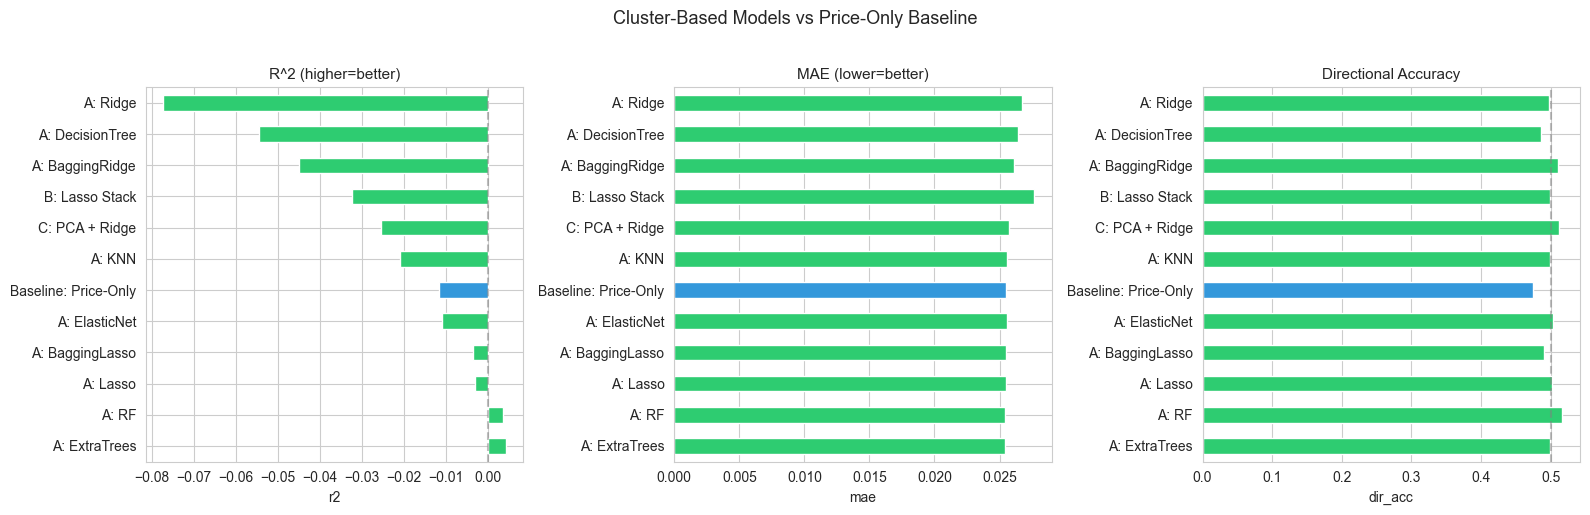

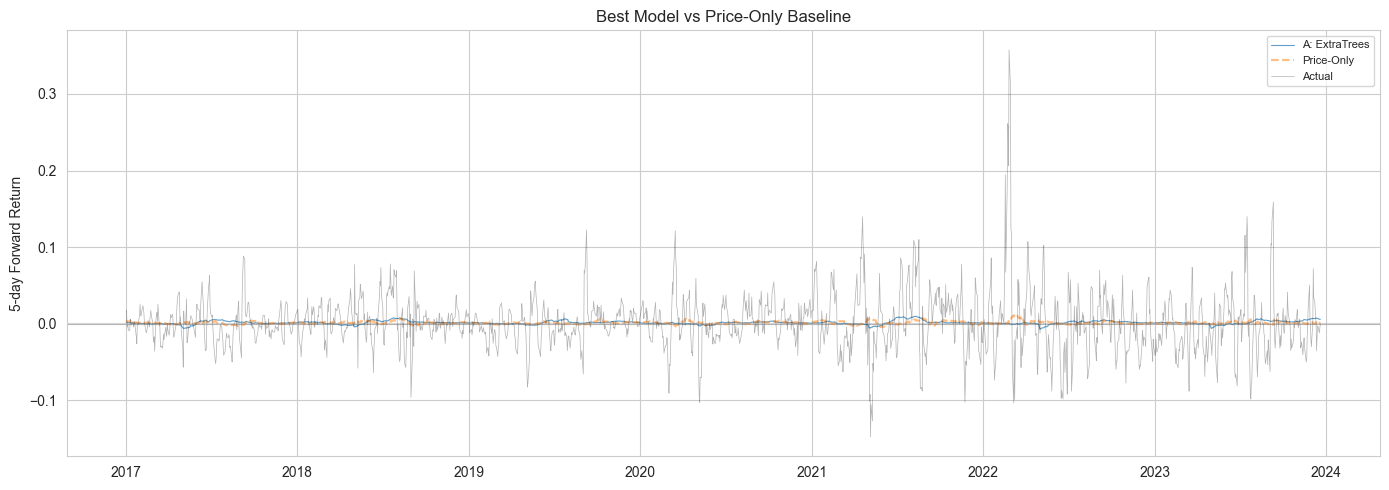

In [38]:
# ============================================================
# Comparison visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(
    axes, ['r2', 'mae', 'dir_acc'],
    ['R^2 (higher=better)', 'MAE (lower=better)', 'Directional Accuracy']
):
    vals = lb_df[metric]
    colors = ['#2ecc71' if 'Baseline' not in n else '#3498db' for n in vals.index]
    vals.plot.barh(ax=ax, color=colors)
    if metric == 'r2':
        ax.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
    elif metric == 'dir_acc':
        ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=11)

plt.suptitle('Cluster-Based Models vs Price-Only Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Time series of best model vs baseline ---
fig, ax = plt.subplots(figsize=(14, 5))
best_name = lb_df.index[0]

# Find predictions for best model
for name in [best_name]:
    if name in approach_a_results:
        preds = approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        preds = approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        preds = approach_c_result['predictions']
    else:
        continue
    ax.plot(preds['Date'], preds['y_pred'], label=name, alpha=0.7, linewidth=0.8)

if baseline_result:
    bp = baseline_result['predictions']
    ax.plot(bp['Date'], bp['y_pred'], label='Price-Only', alpha=0.5, linestyle='--')
    ax.plot(bp['Date'], bp['Fwd_Return'], label='Actual', color='black', alpha=0.3, linewidth=0.5)

ax.axhline(y=0, color='grey', alpha=0.3)
ax.set_ylabel('5-day Forward Return')
ax.set_title('Best Model vs Price-Only Baseline')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# Per-cluster performance breakdown (Approach A: Ridge)
# ============================================================
if 'A: Ridge' in approach_a_results:
    print("\nPer-cluster performance (Ridge):")
    for c, metrics in approach_a_results['A: Ridge']['per_cluster'].items():
        n_members = len(cluster_members.get(c, []))
        countries = {}
        for r in cluster_members.get(c, []):
            cc = r[:2]
            countries[cc] = countries.get(cc, 0) + 1
        country_str = ', '.join(f'{cc}:{n}' for cc, n in sorted(countries.items()))
        print(f"  Cluster {c} ({n_members} regions: {country_str}): "
              f"R2={metrics['r2']:.4f}, Dir={metrics['dir_acc']:.4f}")


Per-cluster performance (Ridge):
  Cluster 0 (177 regions: DE:160, PL:17): R2=-0.0841, Dir=0.4947
  Cluster 1 (145 regions: DE:120, FR:25): R2=-0.1486, Dir=0.5126
  Cluster 2 (76 regions: DE:68, FR:8): R2=-0.0640, Dir=0.4947
  Cluster 3 (3 regions: FR:3): R2=-0.1019, Dir=0.5036
  Cluster 4 (40 regions: FR:40): R2=-0.0886, Dir=0.4913
  Cluster 5 (74 regions: DE:53, FR:21): R2=-0.1329, Dir=0.5008


Top 2 models for backtesting: ['A: ExtraTrees', 'A: RF']

A: ExtraTrees:
  Return: +563.32%  |  B&H: +283.30%  |  Excess: +280.02%
  Sharpe: 1.31  |  MaxDD: -56.15%  |  Win: 52.2%
  Long: 40% of days  |  Flat: 60% of days
  Avg weight when long: 0.81  |  Realised vol: 22.2%
  Trades: 26  |  Costs: 0.0525
  Regime: {'COLD': np.int64(803), 'HOT': np.int64(743), 'NEUTRAL': np.int64(241)}

A: RF:
  Return: +978.37%  |  B&H: +283.30%  |  Excess: +695.07%
  Sharpe: 1.53  |  MaxDD: -54.92%  |  Win: 53.2%
  Long: 34% of days  |  Flat: 66% of days
  Avg weight when long: 0.82  |  Realised vol: 23.8%
  Trades: 42  |  Costs: 0.0725
  Regime: {'HOT': np.int64(905), 'COLD': np.int64(720), 'NEUTRAL': np.int64(162)}



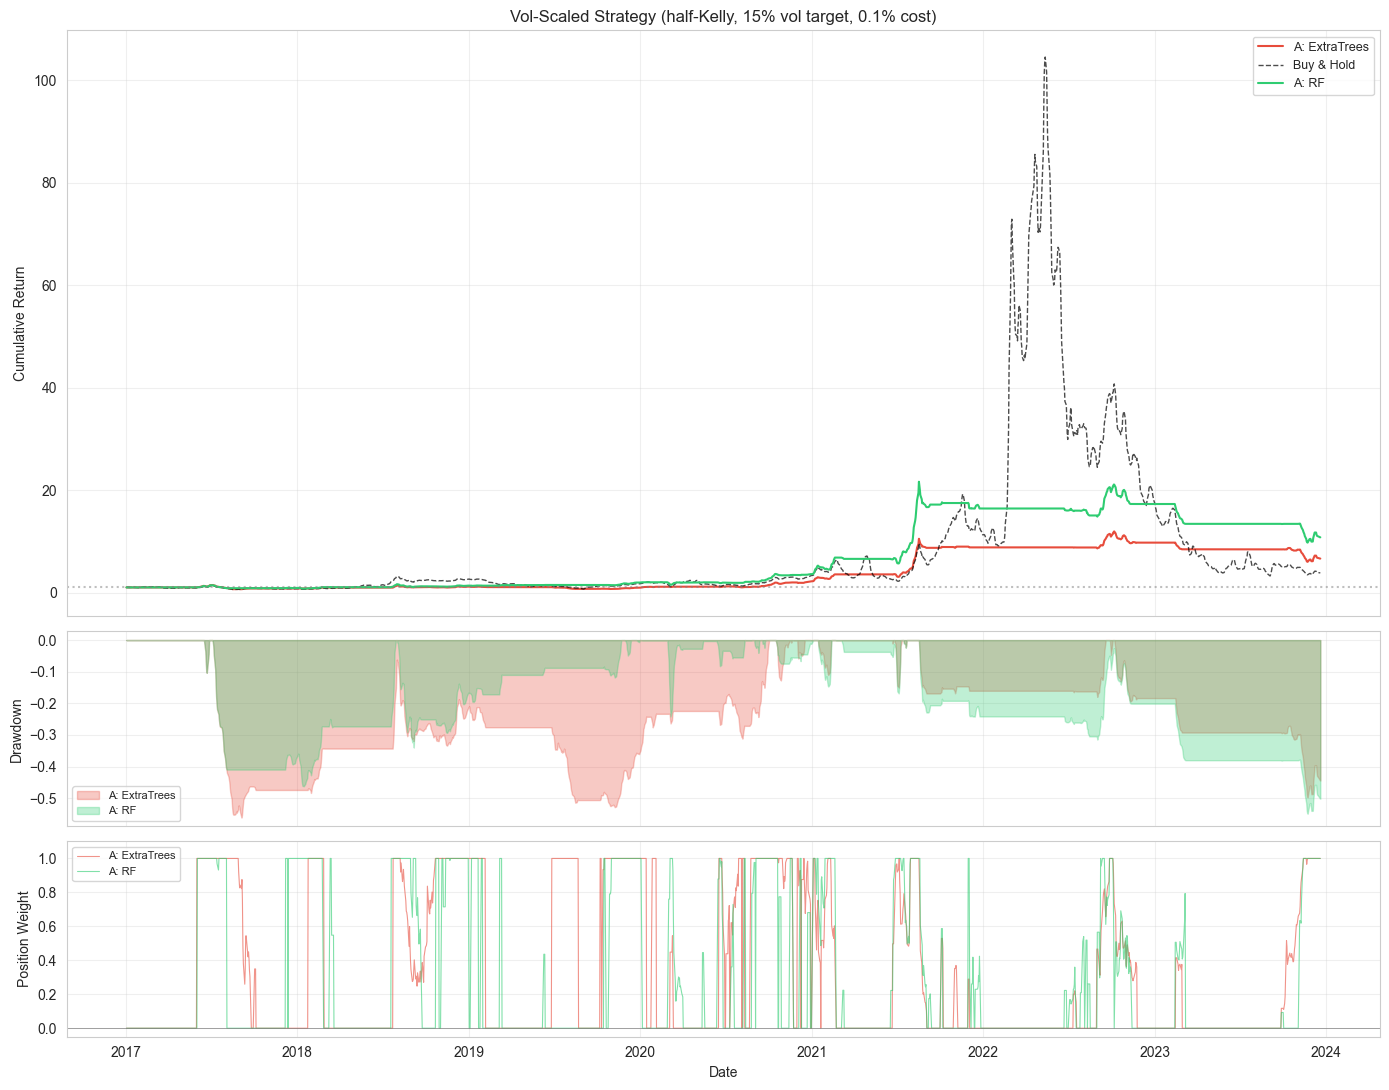

In [40]:
# %% [markdown]
# ---
# ## 7c. Trading Strategy Backtest (Regression Version)
#
# The regression-based strategy exploits three advantages of
# having a continuous predicted return rather than a binary
# direction:
#
# 1. **Volatility scaling** (Moskowitz, Ooi & Pedersen, 2012):
#    Position size is inversely proportional to recent realised
#    volatility. When markets are calm, the strategy sizes up;
#    when markets are volatile, it sizes down.
#
# 2. **Half-Kelly sizing** (Kelly, 1956; Thorp, 2006):
#    The predicted return magnitude determines position weight
#    via the continuous Kelly fraction f* = μ/σ², scaled to
#    half-Kelly for conservatism.
#
# 3. **Adaptive dead-zone** (Lecture 2: bias-variance):
#    The strategy only acts when the predicted return exceeds
#    the model's own recent prediction error — its noise floor.

# %%
# ============================================================
# Trading Strategy — Volatility-Scaled Regression Long/Flat
# ============================================================

TRADE_COST = 0.001
TARGET_VOL = 0.15
VOL_LOOKBACK = 20
KELLY_FRACTION = 0.75
MAX_WEIGHT = 1.0
DEAD_ZONE_FRAC = 0.05

# Pick top 2 models from v4 leaderboard
top2_names = lb_df.index[:2].tolist()
print(f'Top 2 models for backtesting: {top2_names}\n')


def backtest_volscaled(predictions_df, futures_df, trade_cost=0.001,
                       target_vol=0.15, vol_lookback=20,
                       kelly_frac=0.25, max_weight=1.0,
                       dead_zone_frac=0.05,
                       lookback=40, min_hold=3, horizon=5):
    df = predictions_df.merge(
        futures_df[['Date', 'Price']],
        on='Date', how='left'
    ).dropna(subset=['Fwd_Return']).copy().reset_index(drop=True)

    df['rolling_vol'] = df['Fwd_Return'].rolling(vol_lookback, min_periods=10).std() * np.sqrt(252)
    df['rolling_var'] = df['Fwd_Return'].rolling(vol_lookback * 3, min_periods=20).var()

    weights = []
    regimes = []
    dead_zones = []
    past_predictions = []

    for idx in range(len(df)):
        pred_ret = df.loc[idx, 'y_pred']
        actual_return = df.loc[idx, 'Fwd_Return']
        r_vol = df.loc[idx, 'rolling_vol']
        r_var = df.loc[idx, 'rolling_var']

        past_predictions.append((idx, pred_ret, actual_return))

        settled = [(p, a) for (t, p, a) in past_predictions if t <= idx - horizon]
        recent = settled[-lookback:] if len(settled) >= lookback else settled

        if len(recent) >= 10:
            noise_est = np.mean([abs(p - a) for p, a in recent])
            recent_dir_acc = np.mean([1 if (p > 0) == (a > 0) else 0 for p, a in recent])
        else:
            noise_est = 0.01
            recent_dir_acc = 0.50

        dead_zones.append(noise_est)

        if recent_dir_acc >= 0.54:
            regime = 'HOT'
        elif recent_dir_acc <= 0.48:
            regime = 'COLD'
        else:
            regime = 'NEUTRAL'
        regimes.append(regime)

        if pred_ret <= noise_est * dead_zone_frac or np.isnan(r_vol) or r_vol <= 0 or np.isnan(r_var) or r_var <= 0:
            weights.append(0.0)
            continue

        if regime == 'COLD' and (len(weights) == 0 or weights[-1] == 0):
            weights.append(0.0)
            continue

        kelly_weight = kelly_frac * pred_ret / r_var
        vol_scalar = target_vol / r_vol
        raw_weight = kelly_weight * vol_scalar
        final_weight = np.clip(raw_weight, 0.0, max_weight)
        weights.append(final_weight)

    df['weight'] = weights
    df['regime'] = regimes
    df['dead_zone'] = dead_zones

    smoothed = df['weight'].copy()
    hold_counter = 0
    last_nonzero_weight = 0.0
    for idx in range(len(smoothed)):
        if hold_counter > 0:
            smoothed.iloc[idx] = last_nonzero_weight
            hold_counter -= 1
        elif smoothed.iloc[idx] > 0 and (idx == 0 or df['weight'].iloc[idx - 1] == 0):
            last_nonzero_weight = smoothed.iloc[idx]
            hold_counter = min_hold - 1
    df['weight'] = smoothed

    df['position'] = (df['weight'] > 0).astype(float)
    df['strategy_return_gross'] = df['weight'] * df['Fwd_Return']
    df['weight_change'] = df['weight'].diff().abs().fillna(df['weight'].abs())
    df['trade_costs'] = df['weight_change'] * trade_cost
    df['strategy_return'] = df['strategy_return_gross'] - df['trade_costs']
    df['bnh_return'] = df['Fwd_Return']
    df['cum_strategy'] = (1 + df['strategy_return']).cumprod()
    df['cum_bnh'] = (1 + df['bnh_return']).cumprod()

    total_ret = df['cum_strategy'].iloc[-1] - 1
    bnh_ret = df['cum_bnh'].iloc[-1] - 1
    n_trades = ((df['weight'] > 0) & (df['weight'].shift(1).fillna(0) == 0)).sum()
    total_costs = df['trade_costs'].sum()
    n_active = (df['weight'] > 0).sum()
    pct_active = n_active / len(df)
    daily_std = df['strategy_return'].std()
    sharpe = (df['strategy_return'].mean() / daily_std * np.sqrt(252)) if daily_std > 0 else 0
    cum = df['cum_strategy']
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    long_rets = df.loc[df['weight'] > 0, 'strategy_return']
    win_rate = (long_rets > 0).mean() if len(long_rets) > 0 else 0
    flat_days = df[df['weight'] == 0]
    avoided_loss = flat_days['Fwd_Return'].clip(upper=0).sum()
    avg_weight = df.loc[df['weight'] > 0, 'weight'].mean() if n_active > 0 else 0
    realised_vol = df['strategy_return'].std() * np.sqrt(252)
    regime_counts = df['regime'].value_counts()

    return {
        'df': df, 'total_return': total_ret, 'bnh_return': bnh_ret,
        'sharpe': sharpe, 'max_drawdown': max_dd, 'n_trades': n_trades,
        'total_costs': total_costs, 'win_rate': win_rate,
        'pct_active': pct_active, 'regime_counts': regime_counts,
        'avoided_loss': avoided_loss,
        'avg_weight': avg_weight, 'realised_vol': realised_vol,
    }


# ---- Run for top 2 models ----
backtest_results = {}
for name in top2_names:
    # Get predictions from the right source
    if name in approach_a_results:
        preds = approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        preds = approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        preds = approach_c_result['predictions']
    elif name == 'Baseline: Price-Only' and baseline_result:
        preds = baseline_result['predictions']
    else:
        print(f"  {name}: predictions not found, skipping")
        continue

    bt = backtest_volscaled(preds, futures, trade_cost=TRADE_COST,
                            target_vol=TARGET_VOL,
                            vol_lookback=VOL_LOOKBACK,
                            kelly_frac=KELLY_FRACTION,
                            max_weight=MAX_WEIGHT,
                            dead_zone_frac=DEAD_ZONE_FRAC,
                            horizon=FORECAST_HORIZON)
    backtest_results[name] = bt
    excess = bt['total_return'] - bt['bnh_return']
    print(f"{name}:")
    print(f"  Return: {bt['total_return']:+.2%}  |  B&H: {bt['bnh_return']:+.2%}  |  "
          f"Excess: {excess:+.2%}")
    print(f"  Sharpe: {bt['sharpe']:.2f}  |  MaxDD: {bt['max_drawdown']:.2%}  |  "
          f"Win: {bt['win_rate']:.1%}")
    print(f"  Long: {bt['pct_active']:.0%} of days  |  Flat: {1-bt['pct_active']:.0%} of days")
    print(f"  Avg weight when long: {bt['avg_weight']:.2f}  |  "
          f"Realised vol: {bt['realised_vol']:.1%}")
    print(f"  Trades: {bt['n_trades']}  |  Costs: {bt['total_costs']:.4f}")
    print(f"  Regime: {dict(bt['regime_counts'])}")
    print()

# ---- Equity curves ----
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

ax = axes[0]
colors_bt = ['#e74c3c', '#2ecc71']
bnh_plotted = False
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    ax.plot(df_bt['Date'], df_bt['cum_strategy'], label=name,
            color=colors_bt[j % len(colors_bt)], linewidth=1.5)
    if not bnh_plotted:
        ax.plot(df_bt['Date'], df_bt['cum_bnh'], label='Buy & Hold',
                color='black', linewidth=1, linestyle='--', alpha=0.7)
        bnh_plotted = True
ax.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
ax.set_ylabel('Cumulative Return')
ax.set_title(f'Vol-Scaled Strategy (half-Kelly, {TARGET_VOL:.0%} vol target, '
             f'{TRADE_COST*100}% cost)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    cum = df_bt['cum_strategy']
    dd = (cum - cum.cummax()) / cum.cummax()
    ax2.fill_between(df_bt['Date'], dd, 0, alpha=0.3,
                     color=colors_bt[j % len(colors_bt)], label=name)
ax2.set_ylabel('Drawdown')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
for j, name in enumerate(backtest_results.keys()):
    bt = backtest_results[name]
    df_bt = bt['df']
    ax3.plot(df_bt['Date'], df_bt['weight'],
             color=colors_bt[j % len(colors_bt)], alpha=0.6, linewidth=0.8, label=name)
ax3.set_ylabel('Position Weight')
ax3.set_xlabel('Date')
ax3.set_ylim(-0.05, MAX_WEIGHT + 0.1)
ax3.axhline(0, color='grey', linewidth=0.5)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 2 models for regime sampling: ['A: ExtraTrees', 'A: RF']

Test period: 2017-01-02 to 2023-12-20
Generated 40 overlapping 0.5-year windows (step = 2 months)

  A: ExtraTrees: 40 windows evaluated
  A: RF: 40 windows evaluated

REGIME-SAMPLING RESULTS (Vol-Scaled Regression Strategy)

────────────────────────────────────────────────────────────────────────────────
  A: ExtraTrees
────────────────────────────────────────────────────────────────────────────────
  Windows: 40
  Strategy beats B&H: 20/40 (50%)
  Median excess return:  +1.28%
  Mean excess return:    -45.55%
  Mean Sharpe:           0.89
  Worst max drawdown:    -56.15%
  Mean win rate:         46.5%
  Mean % time long:      34%
  Mean avg weight:       0.72
  Mean strategy vol:     17.2%
  Mean B&H vol:          54.3%
  Mean vol reduction:    68%

  Per-regime breakdown:
    Bear / High-Vol       n=16  med_excess=+39.57%  beats_bnh=81%  sharpe=-1.89
    Bear / Mid-Vol        n= 2  med_excess=+29.98%  beats_bnh=100%  shar

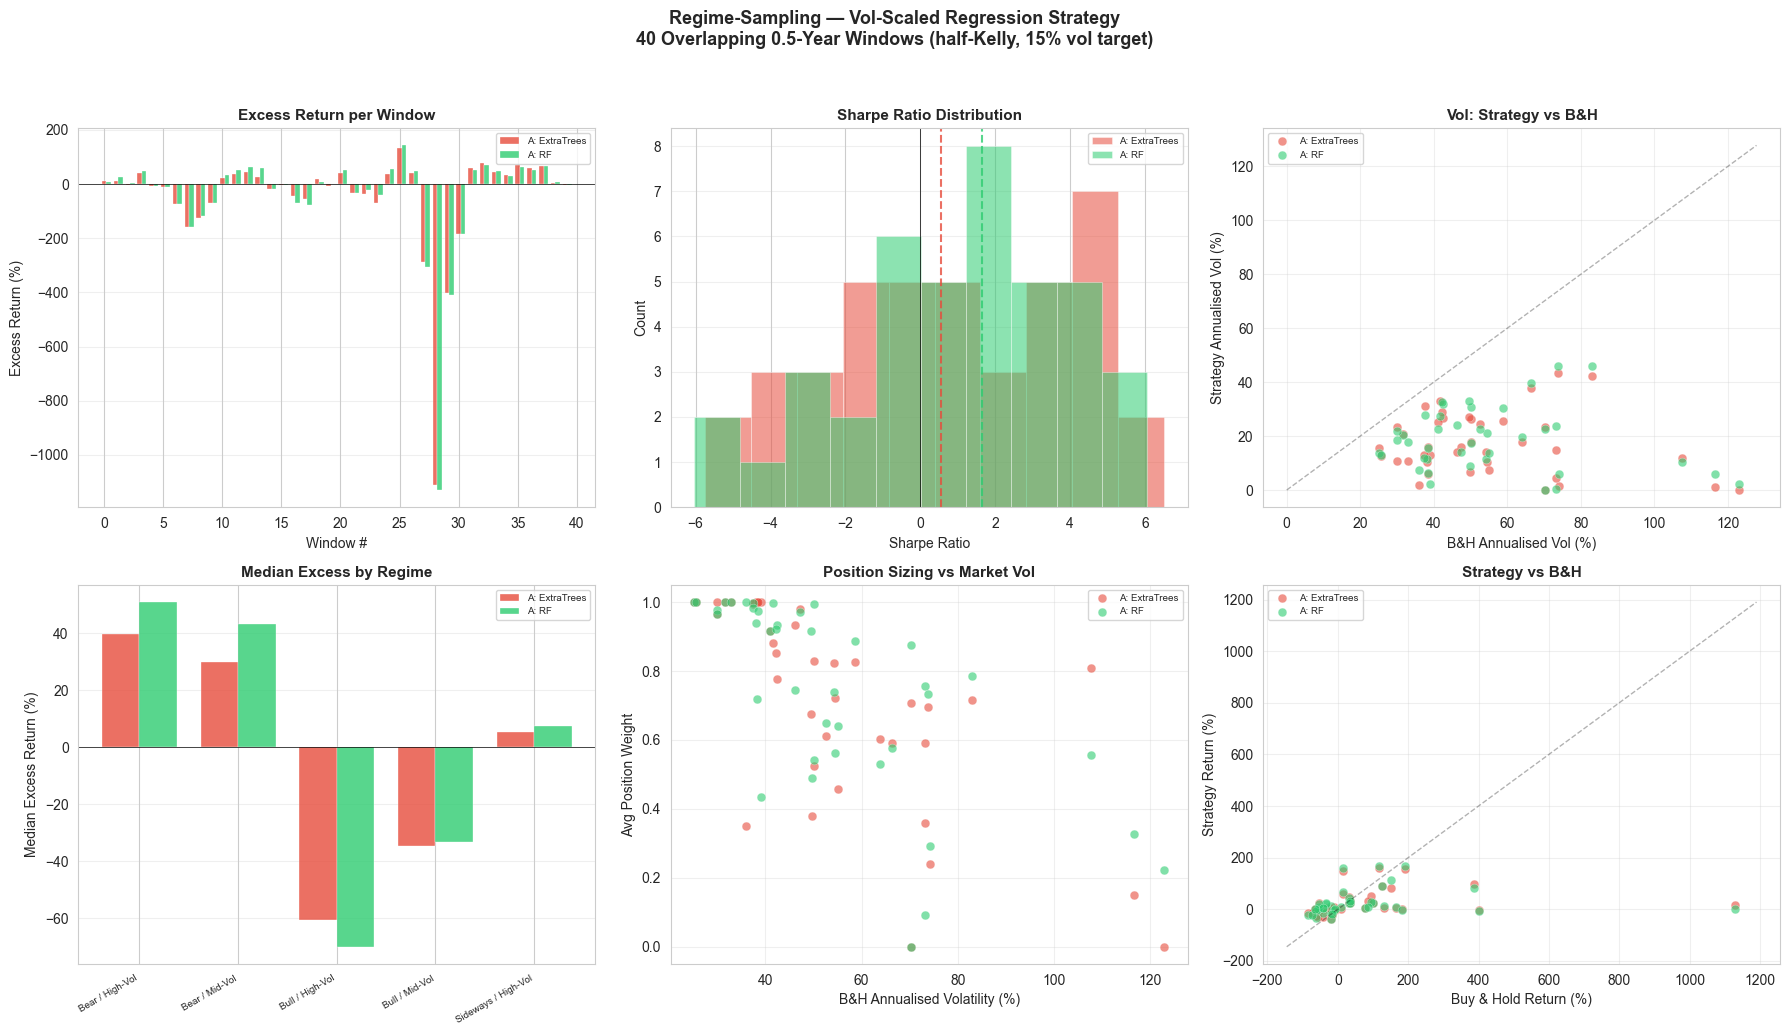

In [41]:
# ============================================================
# Regime-Sampling Backtest (Volatility-Scaled Regression)
# ============================================================

from datetime import timedelta
from collections import defaultdict

WINDOW_YEARS = 0.5
STEP_MONTHS = 2
MIN_DAYS = 100

top2_names = lb_df.index[:2].tolist()
print(f"Top 2 models for regime sampling: {top2_names}\n")

# Helper to get predictions for any model name
def get_predictions(name):
    if name in approach_a_results:
        return approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        return approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        return approach_c_result['predictions']
    elif name == 'Baseline: Price-Only' and baseline_result:
        return baseline_result['predictions']
    return None

# Generate windows
sample_preds = get_predictions(top2_names[0])
test_date_min = sample_preds['Date'].min()
test_date_max = sample_preds['Date'].max()

windows = []
win_start = test_date_min
while win_start + timedelta(days=WINDOW_YEARS * 365) <= test_date_max + timedelta(days=30):
    win_end = win_start + timedelta(days=WINDOW_YEARS * 365)
    windows.append((win_start, min(win_end, test_date_max)))
    win_start += pd.DateOffset(months=STEP_MONTHS)

print(f"Test period: {test_date_min.date()} to {test_date_max.date()}")
print(f"Generated {len(windows)} overlapping {WINDOW_YEARS}-year windows "
      f"(step = {STEP_MONTHS} months)\n")

# Run vol-scaled backtest on each window
regime_results = defaultdict(list)

for model_name in top2_names:
    preds_full = get_predictions(model_name)
    if preds_full is None:
        print(f"  {model_name}: no predictions found, skipping")
        continue

    preds_full = preds_full.copy()

    for i, (ws, we) in enumerate(windows):
        mask = (preds_full['Date'] >= ws) & (preds_full['Date'] <= we)
        preds_window = preds_full[mask].reset_index(drop=True)

        if len(preds_window) < MIN_DAYS:
            continue

        bt = backtest_volscaled(
            preds_window, futures,
            trade_cost=TRADE_COST,
            target_vol=TARGET_VOL,
            vol_lookback=VOL_LOOKBACK,
            kelly_frac=KELLY_FRACTION,
            max_weight=MAX_WEIGHT,
            dead_zone_frac=DEAD_ZONE_FRAC,
            horizon=FORECAST_HORIZON
        )

        bnh_daily_std = bt['df']['Fwd_Return'].std()
        bnh_ann_vol = bnh_daily_std * np.sqrt(252)
        bnh_total = bt['bnh_return']

        if bnh_ann_vol > 0.30:
            vol_label = 'High-Vol'
        elif bnh_ann_vol < 0.18:
            vol_label = 'Low-Vol'
        else:
            vol_label = 'Mid-Vol'

        if bnh_total > 0.15:
            trend_label = 'Bull'
        elif bnh_total < -0.10:
            trend_label = 'Bear'
        else:
            trend_label = 'Sideways'

        regime_results[model_name].append({
            'window': f"{ws.date()} → {we.date()}",
            'start': ws, 'end': we,
            'n_days': len(bt['df']),
            'strategy_ret': bt['total_return'],
            'bnh_ret': bt['bnh_return'],
            'excess': bt['total_return'] - bt['bnh_return'],
            'sharpe': bt['sharpe'],
            'max_dd': bt['max_drawdown'],
            'win_rate': bt['win_rate'],
            'pct_long': bt['pct_active'],
            'avg_weight': bt['avg_weight'],
            'n_trades': bt['n_trades'],
            'strat_ann_vol': bt['realised_vol'],
            'bnh_ann_vol': bnh_ann_vol,
            'regime': f"{trend_label} / {vol_label}",
        })

    print(f"  {model_name}: {len(regime_results[model_name])} windows evaluated")

# Summary
summary_dfs = {}
for model_name in top2_names:
    if model_name not in regime_results:
        continue
    df = pd.DataFrame(regime_results[model_name])
    df = df.sort_values('start').reset_index(drop=True)
    # df = df[df['excess'].abs() <= 10].reset_index(drop=True)
    summary_dfs[model_name] = df

print("\n" + "="*80)
print("REGIME-SAMPLING RESULTS (Vol-Scaled Regression Strategy)")
print("="*80)

for model_name in summary_dfs:
    df = summary_dfs[model_name]
    print(f"\n{'─'*80}")
    print(f"  {model_name}")
    print(f"{'─'*80}")
    print(f"  Windows: {len(df)}")
    print(f"  Strategy beats B&H: {(df['excess'] > 0).sum()}/{len(df)} "
          f"({(df['excess'] > 0).mean():.0%})")
    print(f"  Median excess return:  {df['excess'].median():+.2%}")
    print(f"  Mean excess return:    {df['excess'].mean():+.2%}")
    print(f"  Mean Sharpe:           {df['sharpe'].mean():.2f}")
    print(f"  Worst max drawdown:    {df['max_dd'].min():.2%}")
    print(f"  Mean win rate:         {df['win_rate'].mean():.1%}")
    print(f"  Mean % time long:      {df['pct_long'].mean():.0%}")
    print(f"  Mean avg weight:       {df['avg_weight'].mean():.2f}")
    print(f"  Mean strategy vol:     {df['strat_ann_vol'].mean():.1%}")
    print(f"  Mean B&H vol:          {df['bnh_ann_vol'].mean():.1%}")
    if df['bnh_ann_vol'].mean() > 0:
        print(f"  Mean vol reduction:    "
              f"{(1 - df['strat_ann_vol'].mean() / df['bnh_ann_vol'].mean()):.0%}")

    print(f"\n  Per-regime breakdown:")
    for regime in sorted(df['regime'].unique()):
        sub = df[df['regime'] == regime]
        print(f"    {regime:20s}  n={len(sub):2d}  "
              f"med_excess={sub['excess'].median():+.2%}  "
              f"beats_bnh={sub['excess'].gt(0).mean():.0%}  "
              f"sharpe={sub['sharpe'].mean():.2f}")

# Full window table
for model_name in summary_dfs:
    df = summary_dfs[model_name]
    print(f"\n{'='*80}")
    print(f"  {model_name} — All Windows")
    print(f"{'='*80}")
    display_cols = ['window', 'regime', 'strategy_ret', 'bnh_ret',
                    'excess', 'sharpe', 'max_dd', 'win_rate',
                    'pct_long', 'avg_weight', 'strat_ann_vol', 'bnh_ann_vol']
    print(df[display_cols].to_string(
        index=False,
        formatters={
            'strategy_ret':  '{:+.2%}'.format,
            'bnh_ret':       '{:+.2%}'.format,
            'excess':        '{:+.2%}'.format,
            'sharpe':        '{:.2f}'.format,
            'max_dd':        '{:.2%}'.format,
            'win_rate':      '{:.1%}'.format,
            'pct_long':      '{:.0%}'.format,
            'avg_weight':    '{:.2f}'.format,
            'strat_ann_vol': '{:.1%}'.format,
            'bnh_ann_vol':   '{:.1%}'.format,
        }
    ))

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_colors = {}
color_list = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for j, name in enumerate(summary_dfs.keys()):
    model_colors[name] = color_list[j % len(color_list)]

ax = axes[0, 0]
bar_w = 0.38
for j, name in enumerate(summary_dfs.keys()):
    df = summary_dfs[name]
    vals = df['excess'].values
    ax.bar(np.arange(len(vals)) + j * bar_w, vals * 100, bar_w,
           label=name, color=model_colors[name], alpha=0.8,
           edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Excess Return (%)')
ax.set_title('Excess Return per Window', fontsize=11, fontweight='bold')
ax.set_xlabel('Window #')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.hist(df['sharpe'], bins=10, alpha=0.55, label=name,
            color=model_colors[name], edgecolor='white', linewidth=0.5)
    ax.axvline(df['sharpe'].median(), color=model_colors[name],
               linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Count')
ax.set_title('Sharpe Ratio Distribution', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 2]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ann_vol'] * 100, df['strat_ann_vol'] * 100,
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('B&H Annualised Vol (%)')
ax.set_ylabel('Strategy Annualised Vol (%)')
ax.set_title('Vol: Strategy vs B&H', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[1, 0]
all_regimes = sorted(set(
    r for name in summary_dfs for r in summary_dfs[name]['regime'].unique()
))
x_reg = np.arange(len(all_regimes))
for j, name in enumerate(summary_dfs.keys()):
    df = summary_dfs[name]
    medians = [df[df['regime'] == r]['excess'].median() if r in df['regime'].values else 0
               for r in all_regimes]
    ax.bar(x_reg + j * bar_w, [m * 100 for m in medians], bar_w,
           label=name, color=model_colors[name], alpha=0.8,
           edgecolor='white', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x_reg + bar_w / 2)
ax.set_xticklabels(all_regimes, fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Median Excess Return (%)')
ax.set_title('Median Excess by Regime', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ann_vol'] * 100, df['avg_weight'],
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
ax.set_xlabel('B&H Annualised Volatility (%)')
ax.set_ylabel('Avg Position Weight')
ax.set_title('Position Sizing vs Market Vol', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[1, 2]
for name in summary_dfs:
    df = summary_dfs[name]
    ax.scatter(df['bnh_ret'] * 100, df['strategy_ret'] * 100,
               alpha=0.6, s=40, color=model_colors[name], label=name,
               edgecolors='white', linewidth=0.3)
lims = ax.get_xlim()
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Buy & Hold Return (%)')
ax.set_ylabel('Strategy Return (%)')
ax.set_title('Strategy vs B&H', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

fig.suptitle(f'Regime-Sampling — Vol-Scaled Regression Strategy\n'
             f'{len(windows)} Overlapping {WINDOW_YEARS}-Year Windows '
             f'(half-Kelly, {TARGET_VOL:.0%} vol target)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Research-Grade Next Steps (ML for Finance)

The current notebook is a strong classical benchmark. To move toward state-of-the-art financial forecasting, prioritize three upgrades:

1. **Validation protocol:** purged walk-forward CV with embargo to reduce leakage from overlapping horizons.
2. **Model class:** nonlinear sequence models with panel structure (shared signal across regions + region-specific effects).
3. **Objective + metrics:** optimize and select on economic utility and rank skill, not only point error.

### Candidate model families for this exact setup
- Gradient boosting with constraints: LightGBM / CatBoost / XGBoost.
- Deep sequence panel models: Temporal Fusion Transformer (TFT), TiDE, TSMixer.
- Regime-aware mixtures: hidden-state gating or mixture-of-experts.
- Probabilistic heads: quantile outputs (P10/P50/P90) for uncertainty-aware sizing.


In [42]:
# ============================================================
# SOTA model menu for this notebook (finance-oriented)
# ============================================================

sota_menu = pd.DataFrame([
    {
        'Model family': 'Boosted trees (tabular panel)',
        'Example': 'CatBoost / LightGBM',
        'Why it helps here': 'Strong nonlinear interactions, robust on mixed feature scales, fast walk-forward retraining',
        'Key finance add-on': 'Monotonic constraints + quantile objective for risk-aware forecasts'
    },
    {
        'Model family': 'Sequence transformer (panel TS)',
        'Example': 'Temporal Fusion Transformer (TFT)',
        'Why it helps here': 'Learns long/short temporal dependencies and dynamic variable importance',
        'Key finance add-on': 'Multi-horizon quantiles + attention diagnostics for regime analysis'
    },
    {
        'Model family': 'Modern MLP time-series',
        'Example': 'TiDE / TSMixer',
        'Why it helps here': 'Often competitive with transformers at lower compute and easier tuning',
        'Key finance add-on': 'Stable retrains for frequent re-estimation'
    },
    {
        'Model family': 'Regime-aware mixture',
        'Example': 'Mixture-of-Experts + regime gate',
        'Why it helps here': 'Allows different experts for high-vol, trend, and mean-reversion regimes',
        'Key finance add-on': 'Improves tail behavior and drawdown control'
    }
])

display(sota_menu)


,Model family,Example,Why it helps here,Key finance add-on
0,Boosted trees (tabular panel),CatBoost / LightGBM,"Strong nonlinear interactions, robust on mixed...",Monotonic constraints + quantile objective for...
1,Sequence transformer (panel TS),Temporal Fusion Transformer (TFT),Learns long/short temporal dependencies and dy...,Multi-horizon quantiles + attention diagnostic...
2,Modern MLP time-series,TiDE / TSMixer,Often competitive with transformers at lower c...,Stable retrains for frequent re-estimation
3,Regime-aware mixture,Mixture-of-Experts + regime gate,"Allows different experts for high-vol, trend, ...",Improves tail behavior and drawdown control


In [43]:
# ============================================================
# Sophisticated NN blueprint for this project
# ============================================================

sophisticated_nn_blueprint = {
    'Architecture': 'Multi-task Temporal Fusion Transformer (panel)',
    'Inputs': {
        'Static': ['region embedding', 'country embedding', 'long-run production weight'],
        'Known future': ['calendar features', 'futures term features if available'],
        'Observed past': ['ag features', 'price/volatility features', 'lagged returns']
    },
    'Outputs': ['q10(return_5d)', 'q50(return_5d)', 'q90(return_5d)'],
    'Loss': 'Pinball (quantile) + small directional auxiliary loss',
    'Validation': 'Purged walk-forward with embargo',
    'Why better than simple regression': [
        'Captures nonlinear time-varying feature effects',
        'Shares strength across regions while preserving region-specific behavior',
        'Provides uncertainty bands directly usable for position sizing'
    ]
}

print('Suggested sophisticated NN:')
for k, v in sophisticated_nn_blueprint.items():
    print(f'- {k}: {v}')


Suggested sophisticated NN:
- Architecture: Multi-task Temporal Fusion Transformer (panel)
- Inputs: {'Static': ['region embedding', 'country embedding', 'long-run production weight'], 'Known future': ['calendar features', 'futures term features if available'], 'Observed past': ['ag features', 'price/volatility features', 'lagged returns']}
- Outputs: ['q10(return_5d)', 'q50(return_5d)', 'q90(return_5d)']
- Loss: Pinball (quantile) + small directional auxiliary loss
- Validation: Purged walk-forward with embargo
- Why better than simple regression: ['Captures nonlinear time-varying feature effects', 'Shares strength across regions while preserving region-specific behavior', 'Provides uncertainty bands directly usable for position sizing']


In [44]:
# ============================================================
# Advanced forecast + trading metrics (beyond RMSE/MAE/R2)
# ============================================================

def _max_drawdown_from_returns(ret_series):
    ret_series = pd.Series(ret_series).fillna(0.0)
    equity = (1.0 + ret_series).cumprod()
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def evaluate_forecast_and_strategy(pred_df, ret_col='Fwd_Return', pred_col='y_pred',
                                   freq=252, dead_zone=0.0, trade_cost_bps=0.0):
    """Return both statistical and economic metrics for one model's predictions."""
    df = pred_df[[ret_col, pred_col]].dropna().copy()
    if df.empty:
        return None

    y = df[ret_col].values
    yhat = df[pred_col].values

    # Forecast-quality metrics
    rmse = float(np.sqrt(mean_squared_error(y, yhat)))
    mae = float(mean_absolute_error(y, yhat))
    r2 = float(r2_score(y, yhat))
    pearson_corr = float(pd.Series(y).corr(pd.Series(yhat)))
    rank_ic = float(pd.Series(y).rank().corr(pd.Series(yhat).rank()))
    hit_rate = float(np.mean(np.sign(yhat) == np.sign(y)))

    abs_thr = float(np.nanpercentile(np.abs(y), 75))
    tail_mask = np.abs(y) >= abs_thr
    hit_rate_tail = float(np.mean(np.sign(yhat[tail_mask]) == np.sign(y[tail_mask]))) if tail_mask.any() else np.nan

    q_hi = float(np.nanquantile(yhat, 0.8))
    q_lo = float(np.nanquantile(yhat, 0.2))
    long_mean = float(np.mean(y[yhat >= q_hi])) if np.any(yhat >= q_hi) else np.nan
    short_mean = float(np.mean(y[yhat <= q_lo])) if np.any(yhat <= q_lo) else np.nan
    top_bottom_spread = long_mean - short_mean if np.isfinite(long_mean) and np.isfinite(short_mean) else np.nan

    # Trading metrics from sign strategy (simple and transparent baseline)
    pos = np.sign(yhat)
    if dead_zone > 0:
        pos[np.abs(yhat) < dead_zone] = 0.0
    pos = pd.Series(pos)
    pos_prev = pos.shift(1).fillna(0.0)

    turnover = float((pos - pos_prev).abs().mean())
    gross_ret = pos.values * y
    tc = trade_cost_bps / 1e4
    net_ret = gross_ret - (pos - pos_prev).abs().values * tc
    net_ret = pd.Series(net_ret)

    ann_ret = float((1.0 + net_ret).prod() ** (freq / len(net_ret)) - 1.0)
    ann_vol = float(net_ret.std(ddof=1) * np.sqrt(freq))
    sharpe_net = float((net_ret.mean() / net_ret.std(ddof=1)) * np.sqrt(freq)) if net_ret.std(ddof=1) > 0 else np.nan

    downside = net_ret[net_ret < 0]
    sortino_net = float((net_ret.mean() / downside.std(ddof=1)) * np.sqrt(freq)) if len(downside) > 1 and downside.std(ddof=1) > 0 else np.nan
    max_dd = _max_drawdown_from_returns(net_ret)
    calmar = float(ann_ret / abs(max_dd)) if max_dd < 0 else np.nan

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'pearson_corr': pearson_corr,
        'rank_ic': rank_ic,
        'hit_rate': hit_rate,
        'hit_rate_tail': hit_rate_tail,
        'top_bottom_spread': top_bottom_spread,
        'ann_ret_net': ann_ret,
        'ann_vol_net': ann_vol,
        'sharpe_net': sharpe_net,
        'sortino_net': sortino_net,
        'calmar_net': calmar,
        'max_dd_net': max_dd,
        'turnover': turnover,
    }

def collect_advanced_scores(dead_zone=0.0, trade_cost_bps=2.0):
    model_pred_map = {}

    if 'approach_a_results' in globals():
        for name, res in approach_a_results.items():
            model_pred_map[name] = res['predictions']

    if 'approach_b_result' in globals() and approach_b_result:
        model_pred_map['B: Lasso Stack'] = approach_b_result['predictions']

    if 'approach_c_result' in globals() and approach_c_result:
        model_pred_map['C: PCA + Ridge'] = approach_c_result['predictions']

    if 'baseline_result' in globals() and baseline_result:
        model_pred_map['Baseline'] = baseline_result['predictions']

    records = {}
    for name, preds in model_pred_map.items():
        rec = evaluate_forecast_and_strategy(
            preds,
            ret_col='Fwd_Return',
            pred_col='y_pred',
            freq=252,
            dead_zone=dead_zone,
            trade_cost_bps=trade_cost_bps,
        )
        if rec is not None:
            records[name] = rec

    if not records:
        print('No prediction objects found. Run the modeling cells first.')
        return None

    out = pd.DataFrame(records).T
    out = out.sort_values(['rank_ic', 'sharpe_net'], ascending=False)
    return out

advanced_scores = collect_advanced_scores(dead_zone=0.0, trade_cost_bps=2.0)
if advanced_scores is not None:
    cols = [
        'r2', 'rank_ic', 'hit_rate', 'hit_rate_tail', 'top_bottom_spread',
        'ann_ret_net', 'ann_vol_net', 'sharpe_net', 'sortino_net',
        'calmar_net', 'max_dd_net', 'turnover'
    ]
    display(advanced_scores[cols].style.format({
        'r2': '{:.4f}',
        'rank_ic': '{:.4f}',
        'hit_rate': '{:.2%}',
        'hit_rate_tail': '{:.2%}',
        'top_bottom_spread': '{:.4f}',
        'ann_ret_net': '{:.2%}',
        'ann_vol_net': '{:.2%}',
        'sharpe_net': '{:.2f}',
        'sortino_net': '{:.2f}',
        'calmar_net': '{:.2f}',
        'max_dd_net': '{:.2%}',
        'turnover': '{:.3f}',
    }))


,r2,rank_ic,hit_rate,hit_rate_tail,top_bottom_spread,ann_ret_net,ann_vol_net,sharpe_net,sortino_net,calmar_net,max_dd_net,turnover
A: KNN,-0.0208,0.0556,49.92%,54.59%,0.0053,11.44%,59.11%,0.48,0.68,0.15,-78.61%,0.388
A: ElasticNet,-0.0109,0.0550,50.42%,49.66%,0.0066,5.42%,59.12%,0.39,0.55,0.05,-98.95%,0.088
A: ExtraTrees,0.0044,0.0531,49.92%,52.35%,0.0039,29.30%,59.07%,0.73,1.14,0.31,-95.46%,0.072
A: BaggingRidge,-0.0450,0.0492,51.09%,54.14%,0.0006,13.58%,59.10%,0.52,0.65,0.14,-98.82%,0.182
A: RF,0.0037,0.0417,51.65%,52.13%,0.0016,-7.86%,59.14%,0.17,0.20,-0.08,-99.18%,0.146
A: Ridge,-0.0774,0.0349,49.75%,53.02%,-0.0009,-7.80%,59.13%,0.17,0.21,-0.08,-99.25%,0.177
C: PCA + Ridge,-0.0253,0.0340,51.15%,51.68%,-0.0004,-1.31%,59.13%,0.28,0.35,-0.01,-97.64%,0.194
A: Lasso,-0.0030,0.0201,50.14%,50.34%,0.0045,34.26%,59.06%,0.78,1.36,0.35,-97.77%,0.063
A: BaggingLasso,-0.0035,0.0105,49.02%,48.10%,0.0017,3.62%,59.12%,0.35,0.59,0.04,-98.20%,0.077
A: DecisionTree,-0.0546,-0.0202,48.68%,50.78%,0.0004,9.03%,59.12%,0.43,0.75,0.10,-89.60%,0.095


## Deep Learning Model Zoo (GPU, tuning, validation, full comparison)

This section adds complete trainable neural models and compares them directly with all classical models already in this notebook.

What is implemented:
- GPU-aware training loop (CUDA if available, otherwise CPU fallback).
- Walk-forward evaluation by test year (same 2017-2023 protocol).
- Per-fold hyperparameter search on an in-training validation split.
- Early stopping + weight decay + dropout.
- Unified prediction objects and metrics for direct comparison with `approach_a/b/c` and `baseline`.

Models:
- `MLP` on flattened lookback windows.
- `LSTM` sequence regressor.
- `Transformer` encoder regressor.


In [45]:
# ============================================================
# Deep learning environment setup
# ============================================================

import copy
import math
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.backends.cudnn.benchmark = True
else:
    print('CUDA not available in current runtime. The same code will use GPU automatically when run on a CUDA machine.')


Device: cpu
CUDA not available in current runtime. The same code will use GPU automatically when run on a CUDA machine.


In [46]:
# ============================================================
# Sequence data utilities + model definitions
# ============================================================

def build_sequence_arrays_from_scaled_features(X_scaled, y, dates, years, lookback):
    """Build sliding windows ending at time t to predict y[t]."""
    X_seq, y_seq, d_seq, yr_seq = [], [], [], []
    n = len(y)
    for t in range(lookback - 1, n):
        X_seq.append(X_scaled[t - lookback + 1:t + 1])
        y_seq.append(y[t])
        d_seq.append(dates[t])
        yr_seq.append(years[t])
    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(d_seq),
        np.asarray(yr_seq, dtype=np.int32),
    )

def time_train_val_masks(train_years, min_val_size=64):
    """Validation is the last year in the training span; fallback to chronological split."""
    uniq = np.sort(np.unique(train_years))
    if len(uniq) >= 2:
        val_year = uniq[-1]
        tr = train_years < val_year
        va = train_years == val_year
        if tr.sum() >= min_val_size and va.sum() >= min_val_size:
            return tr, va

    n = len(train_years)
    cut = int(n * 0.8)
    tr = np.zeros(n, dtype=bool)
    tr[:cut] = True
    va = ~tr
    return tr, va

def make_regression_loaders(X_train, y_train, X_val, y_val, batch_size=256, num_workers=0, pin_memory=False):
    ds_train = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    ds_val = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    tr_loader = DataLoader(
        ds_train, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory
    )
    va_loader = DataLoader(
        ds_val, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory
    )
    return tr_loader, va_loader

def make_predict_loader(X, batch_size=512, num_workers=0, pin_memory=False):
    ds = TensorDataset(torch.from_numpy(X))
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

class SeqMLP(nn.Module):
    def __init__(self, input_dim, lookback, hidden=256, dropout=0.2):
        super().__init__()
        in_dim = input_dim * lookback
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        b = x.size(0)
        x = x.reshape(b, -1)
        return self.net(x)

class SeqLSTM(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)

class SeqTransformer(nn.Module):
    def __init__(self, input_dim, lookback, d_model=96, nhead=4, num_layers=2, ff_dim=192, dropout=0.1):
        super().__init__()
        self.lookback = lookback
        self.in_proj = nn.Linear(input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, lookback, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        z = self.in_proj(x) + self.pos_embed[:, :x.size(1), :]
        h = self.encoder(z)
        return self.head(h[:, -1, :])

def make_model(model_name, input_dim, lookback, params):
    if model_name == 'MLP':
        return SeqMLP(input_dim=input_dim, lookback=lookback, hidden=params['hidden'], dropout=params['dropout'])
    if model_name == 'LSTM':
        return SeqLSTM(input_dim=input_dim, hidden=params['hidden'], num_layers=params['num_layers'], dropout=params['dropout'])
    if model_name == 'Transformer':
        return SeqTransformer(
            input_dim=input_dim,
            lookback=lookback,
            d_model=params['d_model'],
            nhead=params['nhead'],
            num_layers=params['num_layers'],
            ff_dim=params['ff_dim'],
            dropout=params['dropout'],
        )
    raise ValueError(f'Unknown model_name: {model_name}')

def fit_with_early_stopping(model, train_loader, val_loader, *, lr, weight_decay, max_epochs, patience, device):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    bad_epochs = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                pred = model(xb).squeeze(-1)
                loss = loss_fn(pred, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                pred = model(xb).squeeze(-1)
                val_losses.append(nn.functional.mse_loss(pred, yb).item())

        val_mse = float(np.mean(val_losses)) if val_losses else float('inf')
        if val_mse < best_val:
            best_val = val_mse
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val

def predict_batches(model, pred_loader, device):
    model.eval()
    preds = []
    with torch.no_grad():
        for (xb,) in pred_loader:
            xb = xb.to(device, non_blocking=True)
            yhat = model(xb).squeeze(-1).detach().cpu().numpy()
            preds.append(yhat)
    return np.concatenate(preds) if preds else np.array([], dtype=np.float32)

def overall_metrics_from_pred_df(pred_df):
    return {
        'mse': mean_squared_error(pred_df['Fwd_Return'], pred_df['y_pred']),
        'mae': mean_absolute_error(pred_df['Fwd_Return'], pred_df['y_pred']),
        'r2': r2_score(pred_df['Fwd_Return'], pred_df['y_pred']),
        'dir_acc': float(np.mean(np.sign(pred_df['y_pred']) == np.sign(pred_df['Fwd_Return']))),
    }


In [47]:
# ============================================================
# Train + tune deep models with walk-forward validation
# ============================================================

if 'wide_df' not in globals() or 'ag_wide_cols' not in globals():
    raise RuntimeError('Run the data preparation and classical modeling cells first (wide_df/ag_wide_cols missing).')

feature_cols_dl = price_feature_cols + ag_wide_cols

work_df = wide_df[['Date', 'Fwd_Return'] + feature_cols_dl].copy().sort_values('Date').reset_index(drop=True)
work_df = work_df.dropna(subset=['Fwd_Return']).copy()
for c in feature_cols_dl:
    work_df[c] = work_df[c].ffill().fillna(0.0)

X_rows_raw = work_df[feature_cols_dl].values.astype(np.float32)
y_rows = work_df['Fwd_Return'].values.astype(np.float32)
dates_rows = work_df['Date'].values
years_rows = work_df['Date'].dt.year.values.astype(np.int32)

LOOKBACK = 20
BATCH_SIZE = 256 if device.type == 'cuda' else 128
MAX_EPOCHS = 35
PATIENCE = 6
NUM_WORKERS = 0
PIN_MEMORY = (device.type == 'cuda')

param_space = {
    'MLP': [
        {'hidden': 256, 'dropout': 0.20, 'lr': 1e-3, 'weight_decay': 1e-5},
        {'hidden': 384, 'dropout': 0.25, 'lr': 7e-4, 'weight_decay': 1e-4},
        {'hidden': 512, 'dropout': 0.30, 'lr': 5e-4, 'weight_decay': 1e-4},
    ],
    'LSTM': [
        {'hidden': 64, 'num_layers': 1, 'dropout': 0.10, 'lr': 1e-3, 'weight_decay': 1e-5},
        {'hidden': 96, 'num_layers': 2, 'dropout': 0.20, 'lr': 7e-4, 'weight_decay': 1e-4},
        {'hidden': 128, 'num_layers': 2, 'dropout': 0.25, 'lr': 5e-4, 'weight_decay': 1e-4},
    ],
    'Transformer': [
        {'d_model': 64, 'nhead': 4, 'num_layers': 2, 'ff_dim': 128, 'dropout': 0.10, 'lr': 8e-4, 'weight_decay': 1e-5},
        {'d_model': 96, 'nhead': 4, 'num_layers': 2, 'ff_dim': 192, 'dropout': 0.15, 'lr': 6e-4, 'weight_decay': 1e-4},
        {'d_model': 128, 'nhead': 8, 'num_layers': 2, 'ff_dim': 256, 'dropout': 0.20, 'lr': 4e-4, 'weight_decay': 1e-4},
    ],
}

deep_results = {}

for model_name, candidates in param_space.items():
    print('\n' + '=' * 70)
    print(f'DEEP MODEL: {model_name}')
    print('=' * 70)

    fold_pred_dfs = []
    fold_rows = []

    for test_year in range(test_start_year, test_end_year + 1):
        row_train_mask = years_rows < test_year
        row_test_mask = years_rows == test_year
        if row_train_mask.sum() < 400 or row_test_mask.sum() < 40:
            continue

        scaler_fold = StandardScaler()
        scaler_fold.fit(X_rows_raw[row_train_mask])
        X_rows_scaled = scaler_fold.transform(X_rows_raw).astype(np.float32)

        X_seq, y_seq, d_seq, yr_seq = build_sequence_arrays_from_scaled_features(
            X_rows_scaled, y_rows, dates_rows, years_rows, LOOKBACK
        )

        train_mask = yr_seq < test_year
        test_mask = yr_seq == test_year
        if train_mask.sum() < 300 or test_mask.sum() < 30:
            continue

        X_train_all = X_seq[train_mask]
        y_train_all = y_seq[train_mask]
        train_years = yr_seq[train_mask]

        X_test = X_seq[test_mask]
        y_test = y_seq[test_mask]
        d_test = d_seq[test_mask]

        tr_mask, va_mask = time_train_val_masks(train_years, min_val_size=64)
        X_tr, y_tr = X_train_all[tr_mask], y_train_all[tr_mask]
        X_va, y_va = X_train_all[va_mask], y_train_all[va_mask]

        if len(X_tr) < 128 or len(X_va) < 64:
            continue

        tr_loader, va_loader = make_regression_loaders(
            X_tr, y_tr, X_va, y_va,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
        )

        best_params = None
        best_val = float('inf')

        for params in candidates:
            model = make_model(
                model_name=model_name,
                input_dim=X_train_all.shape[-1],
                lookback=LOOKBACK,
                params=params,
            ).to(device)

            tuned_model, val_mse = fit_with_early_stopping(
                model,
                tr_loader,
                va_loader,
                lr=params['lr'],
                weight_decay=params['weight_decay'],
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                device=device,
            )

            if val_mse < best_val:
                best_val = val_mse
                best_params = params

        # Refit using all pre-test data with an internal chronological holdout
        cut = int(len(X_train_all) * 0.9)
        cut = max(cut, 128)
        cut = min(cut, len(X_train_all) - 64) if len(X_train_all) > 192 else int(len(X_train_all) * 0.8)

        X_fit_tr, y_fit_tr = X_train_all[:cut], y_train_all[:cut]
        X_fit_va, y_fit_va = X_train_all[cut:], y_train_all[cut:]

        fit_tr_loader, fit_va_loader = make_regression_loaders(
            X_fit_tr, y_fit_tr, X_fit_va, y_fit_va,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
        )

        final_model = make_model(
            model_name=model_name,
            input_dim=X_train_all.shape[-1],
            lookback=LOOKBACK,
            params=best_params,
        ).to(device)

        final_model, _ = fit_with_early_stopping(
            final_model,
            fit_tr_loader,
            fit_va_loader,
            lr=best_params['lr'],
            weight_decay=best_params['weight_decay'],
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        pred_loader = make_predict_loader(X_test, batch_size=512, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        y_pred = predict_batches(final_model, pred_loader, device)

        fold_df = pd.DataFrame({
            'Date': pd.to_datetime(d_test),
            'Fwd_Return': y_test,
            'y_pred': y_pred,
        })
        fold_pred_dfs.append(fold_df)

        fold_r2 = r2_score(y_test, y_pred)
        fold_dir = float(np.mean(np.sign(y_pred) == np.sign(y_test)))
        fold_rows.append({
            'year': test_year,
            'r2': fold_r2,
            'dir_acc': fold_dir,
            'best_params': best_params,
        })
        print(f'  {test_year}: R2={fold_r2:.4f}, Dir={fold_dir:.4f}, params={best_params}')

    if fold_pred_dfs:
        all_preds = pd.concat(fold_pred_dfs, ignore_index=True).sort_values('Date').reset_index(drop=True)
        overall = overall_metrics_from_pred_df(all_preds)
        deep_results[f'D: {model_name}'] = {
            'predictions': all_preds,
            'overall': overall,
            'yearly': pd.DataFrame(fold_rows),
        }
        print(f"  OVERALL -> R2={overall['r2']:.4f}, MAE={overall['mae']:.4f}, Dir={overall['dir_acc']:.4f}")
    else:
        print('  No valid folds were produced for this model.')

print('\nDeep models trained:', list(deep_results.keys()))



DEEP MODEL: MLP
  2017: R2=-0.1198, Dir=0.5255, params={'hidden': 384, 'dropout': 0.25, 'lr': 0.0007, 'weight_decay': 0.0001}
  2018: R2=-0.0120, Dir=0.5647, params={'hidden': 512, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001}
  2019: R2=-0.1120, Dir=0.4157, params={'hidden': 256, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-05}
  2020: R2=-0.0720, Dir=0.5136, params={'hidden': 384, 'dropout': 0.25, 'lr': 0.0007, 'weight_decay': 0.0001}
  2021: R2=-0.1464, Dir=0.5039, params={'hidden': 256, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-05}
  2022: R2=-0.0541, Dir=0.5136, params={'hidden': 512, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001}
  2023: R2=-0.0940, Dir=0.4480, params={'hidden': 512, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001}
  OVERALL -> R2=-0.0741, MAE=0.0265, Dir=0.4980

DEEP MODEL: LSTM
  2017: R2=-0.3110, Dir=0.4588, params={'hidden': 128, 'num_layers': 2, 'dropout': 0.25, 'lr': 0.0005, 'weight_decay': 0.0001}
  2018: R2=-0.2915, Dir=0.525

KeyboardInterrupt: 


FULL LEADERBOARD (CLASSICAL + DEEP)


,mse,mae,r2,dir_acc
A: ExtraTrees,0.001379,0.025413,0.0044,49.92%
A: RF,0.001380,0.025428,0.0037,51.65%
A: Lasso,0.001389,0.025471,-0.0030,50.14%
A: BaggingLasso,0.001390,0.025473,-0.0035,49.02%
A: ElasticNet,0.001400,0.025565,-0.0109,50.42%
A: KNN,0.001414,0.025598,-0.0208,49.92%
A: BaggingRidge,0.001447,0.026125,-0.0450,51.09%
A: DecisionTree,0.001460,0.026392,-0.0546,48.68%
A: Ridge,0.001492,0.026703,-0.0774,49.75%


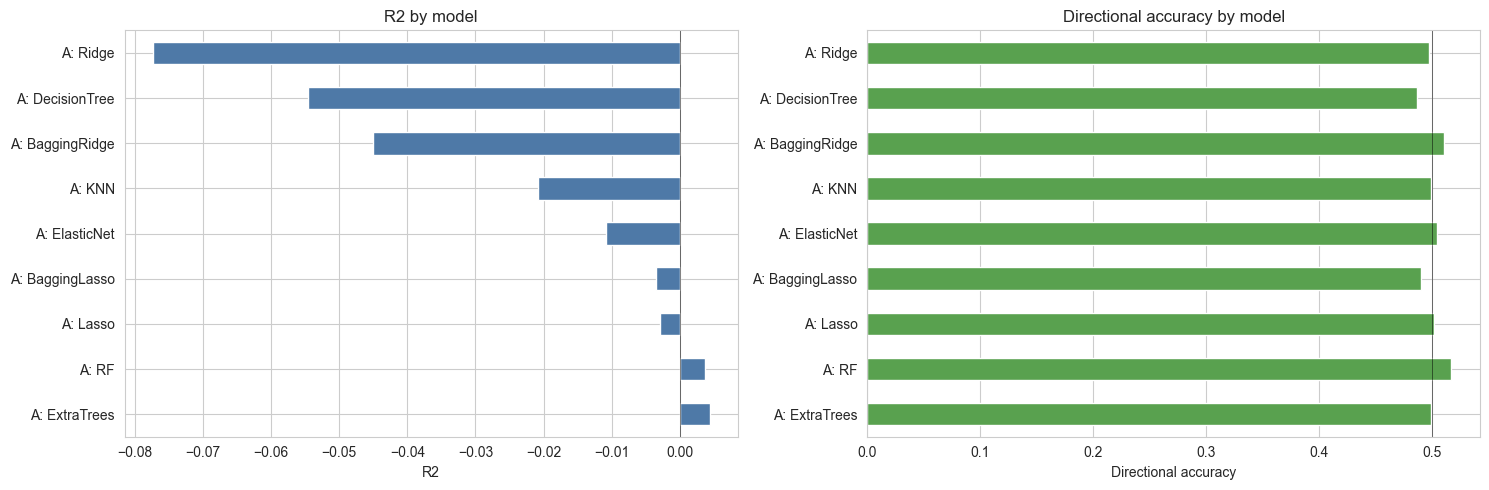

In [ ]:
# ============================================================
# Unified leaderboard: classical + deep models
# ============================================================

all_results = {}

if 'approach_a_results' in globals():
    for name, res in approach_a_results.items():
        all_results[name] = res['overall']

if 'approach_b_result' in globals() and approach_b_result:
    all_results['B: Lasso Stack'] = approach_b_result['overall']

if 'approach_c_result' in globals() and approach_c_result:
    all_results['C: PCA + Ridge'] = approach_c_result['overall']

if 'baseline_result' in globals() and baseline_result:
    all_results['Baseline: Price-Only'] = baseline_result['overall']

if 'deep_results' in globals():
    for name, res in deep_results.items():
        all_results[name] = res['overall']

if not all_results:
    raise RuntimeError('No model results available. Run model cells first.')

full_lb_df = pd.DataFrame(all_results).T.sort_values('r2', ascending=False)
print('\n' + '=' * 80)
print('FULL LEADERBOARD (CLASSICAL + DEEP)')
print('=' * 80)
display(full_lb_df.style.format({
    'mse': '{:.6f}',
    'mae': '{:.6f}',
    'r2': '{:.4f}',
    'dir_acc': '{:.2%}',
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
full_lb_df['r2'].plot(kind='barh', ax=axes[0], color='#4e79a7')
axes[0].axvline(0, color='black', linewidth=0.7, alpha=0.5)
axes[0].set_title('R2 by model')
axes[0].set_xlabel('R2')

full_lb_df['dir_acc'].plot(kind='barh', ax=axes[1], color='#59a14f')
axes[1].axvline(0.5, color='black', linewidth=0.7, alpha=0.5)
axes[1].set_title('Directional accuracy by model')
axes[1].set_xlabel('Directional accuracy')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Advanced finance metrics for all models (including deep)
# ============================================================

def collect_advanced_scores_all(dead_zone=0.0, trade_cost_bps=2.0):
    model_pred_map = {}

    if 'approach_a_results' in globals():
        for name, res in approach_a_results.items():
            model_pred_map[name] = res['predictions']

    if 'approach_b_result' in globals() and approach_b_result:
        model_pred_map['B: Lasso Stack'] = approach_b_result['predictions']

    if 'approach_c_result' in globals() and approach_c_result:
        model_pred_map['C: PCA + Ridge'] = approach_c_result['predictions']

    if 'baseline_result' in globals() and baseline_result:
        model_pred_map['Baseline: Price-Only'] = baseline_result['predictions']

    if 'deep_results' in globals():
        for name, res in deep_results.items():
            model_pred_map[name] = res['predictions']

    records = {}
    for name, preds in model_pred_map.items():
        rec = evaluate_forecast_and_strategy(
            preds,
            ret_col='Fwd_Return',
            pred_col='y_pred',
            freq=252,
            dead_zone=dead_zone,
            trade_cost_bps=trade_cost_bps,
        )
        if rec is not None:
            records[name] = rec

    if not records:
        return None

    out = pd.DataFrame(records).T
    out = out.sort_values(['rank_ic', 'sharpe_net'], ascending=False)
    return out

advanced_scores_all = collect_advanced_scores_all(dead_zone=0.0, trade_cost_bps=2.0)
if advanced_scores_all is not None:
    cols = [
        'r2', 'rank_ic', 'hit_rate', 'hit_rate_tail', 'top_bottom_spread',
        'ann_ret_net', 'ann_vol_net', 'sharpe_net', 'sortino_net',
        'calmar_net', 'max_dd_net', 'turnover'
    ]
    print('\n' + '=' * 80)
    print('ADVANCED METRICS (ALL MODELS)')
    print('=' * 80)
    display(advanced_scores_all[cols].style.format({
        'r2': '{:.4f}',
        'rank_ic': '{:.4f}',
        'hit_rate': '{:.2%}',
        'hit_rate_tail': '{:.2%}',
        'top_bottom_spread': '{:.4f}',
        'ann_ret_net': '{:.2%}',
        'ann_vol_net': '{:.2%}',
        'sharpe_net': '{:.2f}',
        'sortino_net': '{:.2f}',
        'calmar_net': '{:.2f}',
        'max_dd_net': '{:.2%}',
        'turnover': '{:.3f}',
    }))
else:
    print('No advanced scores available. Run model cells first.')


## Optuna tuning + Quantile Deep Model + Statistical Significance Tests

This section implements three requested upgrades:

1. **Optuna (Bayesian) tuning** for deep models in each walk-forward fold.
2. **Probabilistic deep model** (quantile LSTM with pinball loss).
3. **Statistical testing** of model superiority: Diebold-Mariano and block-bootstrap Sharpe difference.


In [ ]:
# ============================================================
# Optional Optuna import
# ============================================================

try:
    import optuna
    HAS_OPTUNA = True
    print(f'Optuna available: {optuna.__version__}')
except Exception:
    HAS_OPTUNA = False
    print('Optuna not installed. Fallback to random candidate search will be used.')


In [ ]:
# ============================================================
# Optuna tuning for deep mean-regression models
# ============================================================

def _sample_deep_params(trial, model_name):
    if model_name == 'LSTM':
        return {
            'hidden': trial.suggest_int('hidden', 48, 160, step=16),
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'dropout': trial.suggest_float('dropout', 0.05, 0.35),
            'lr': trial.suggest_float('lr', 2e-4, 2e-3, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-6, 2e-3, log=True),
        }
    if model_name == 'Transformer':
        d_model = trial.suggest_categorical('d_model', [64, 96, 128])
        nhead = trial.suggest_categorical('nhead', [4, 8])
        if d_model % nhead != 0:
            nhead = 4
        return {
            'd_model': d_model,
            'nhead': nhead,
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'ff_dim': trial.suggest_categorical('ff_dim', [128, 192, 256, 320]),
            'dropout': trial.suggest_float('dropout', 0.05, 0.30),
            'lr': trial.suggest_float('lr', 2e-4, 2e-3, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-6, 2e-3, log=True),
        }
    raise ValueError(f'Unsupported model_name for Optuna tuning: {model_name}')

def _fallback_random_params(model_name, n_trials=12):
    rng = np.random.default_rng(SEED)
    out = []
    for _ in range(n_trials):
        if model_name == 'LSTM':
            out.append({
                'hidden': int(rng.choice(np.arange(48, 176, 16))),
                'num_layers': int(rng.integers(1, 4)),
                'dropout': float(rng.uniform(0.05, 0.35)),
                'lr': float(np.exp(rng.uniform(np.log(2e-4), np.log(2e-3)))),
                'weight_decay': float(np.exp(rng.uniform(np.log(1e-6), np.log(2e-3)))),
            })
        elif model_name == 'Transformer':
            d_model = int(rng.choice([64, 96, 128]))
            nhead = int(rng.choice([4, 8]))
            if d_model % nhead != 0:
                nhead = 4
            out.append({
                'd_model': d_model,
                'nhead': nhead,
                'num_layers': int(rng.integers(1, 4)),
                'ff_dim': int(rng.choice([128, 192, 256, 320])),
                'dropout': float(rng.uniform(0.05, 0.30)),
                'lr': float(np.exp(rng.uniform(np.log(2e-4), np.log(2e-3)))),
                'weight_decay': float(np.exp(rng.uniform(np.log(1e-6), np.log(2e-3)))),
            })
        else:
            raise ValueError(model_name)
    return out

def tune_params_deep_fold(model_name, X_tr, y_tr, X_va, y_va, *, input_dim, lookback, n_trials=15):
    tr_loader, va_loader = make_regression_loaders(
        X_tr, y_tr, X_va, y_va,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    if HAS_OPTUNA:
        sampler = optuna.samplers.TPESampler(seed=SEED)
        study = optuna.create_study(direction='minimize', sampler=sampler)

        def objective(trial):
            params = _sample_deep_params(trial, model_name)
            model = make_model(model_name, input_dim, lookback, params).to(device)
            _, val_mse = fit_with_early_stopping(
                model,
                tr_loader,
                va_loader,
                lr=params['lr'],
                weight_decay=params['weight_decay'],
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                device=device,
            )
            return val_mse

        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return study.best_params, float(study.best_value)

    # Fallback: random search over sampled candidates
    best_params, best_val = None, float('inf')
    for params in _fallback_random_params(model_name, n_trials=n_trials):
        model = make_model(model_name, input_dim, lookback, params).to(device)
        _, val_mse = fit_with_early_stopping(
            model,
            tr_loader,
            va_loader,
            lr=params['lr'],
            weight_decay=params['weight_decay'],
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )
        if val_mse < best_val:
            best_val = val_mse
            best_params = params
    return best_params, float(best_val)


In [ ]:
# ============================================================
# Walk-forward training for Optuna-tuned deep mean models
# ============================================================

if 'work_df' not in globals():
    raise RuntimeError('Run the deep model setup cells first (work_df not found).')

N_TRIALS_OPTUNA = 12
optuna_deep_results = {}
optuna_model_list = ['LSTM', 'Transformer']

for model_name in optuna_model_list:
    print('\n' + '=' * 70)
    print(f'OPTUNA DEEP MODEL: {model_name}')
    print('=' * 70)

    fold_pred_dfs = []
    fold_rows = []

    for test_year in range(test_start_year, test_end_year + 1):
        row_train_mask = years_rows < test_year
        row_test_mask = years_rows == test_year
        if row_train_mask.sum() < 400 or row_test_mask.sum() < 40:
            continue

        scaler_fold = StandardScaler()
        scaler_fold.fit(X_rows_raw[row_train_mask])
        X_rows_scaled = scaler_fold.transform(X_rows_raw).astype(np.float32)

        X_seq, y_seq, d_seq, yr_seq = build_sequence_arrays_from_scaled_features(
            X_rows_scaled, y_rows, dates_rows, years_rows, LOOKBACK
        )

        train_mask = yr_seq < test_year
        test_mask = yr_seq == test_year
        if train_mask.sum() < 300 or test_mask.sum() < 30:
            continue

        X_train_all = X_seq[train_mask]
        y_train_all = y_seq[train_mask]
        train_years = yr_seq[train_mask]
        X_test = X_seq[test_mask]
        y_test = y_seq[test_mask]
        d_test = d_seq[test_mask]

        tr_mask, va_mask = time_train_val_masks(train_years, min_val_size=64)
        X_tr, y_tr = X_train_all[tr_mask], y_train_all[tr_mask]
        X_va, y_va = X_train_all[va_mask], y_train_all[va_mask]

        if len(X_tr) < 128 or len(X_va) < 64:
            continue

        best_params, best_val = tune_params_deep_fold(
            model_name,
            X_tr,
            y_tr,
            X_va,
            y_va,
            input_dim=X_train_all.shape[-1],
            lookback=LOOKBACK,
            n_trials=N_TRIALS_OPTUNA,
        )

        cut = int(len(X_train_all) * 0.9)
        cut = max(cut, 128)
        cut = min(cut, len(X_train_all) - 64) if len(X_train_all) > 192 else int(len(X_train_all) * 0.8)
        X_fit_tr, y_fit_tr = X_train_all[:cut], y_train_all[:cut]
        X_fit_va, y_fit_va = X_train_all[cut:], y_train_all[cut:]

        fit_tr_loader, fit_va_loader = make_regression_loaders(
            X_fit_tr, y_fit_tr, X_fit_va, y_fit_va,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
        )

        final_model = make_model(
            model_name=model_name,
            input_dim=X_train_all.shape[-1],
            lookback=LOOKBACK,
            params=best_params,
        ).to(device)

        final_model, _ = fit_with_early_stopping(
            final_model,
            fit_tr_loader,
            fit_va_loader,
            lr=best_params['lr'],
            weight_decay=best_params['weight_decay'],
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
        )

        pred_loader = make_predict_loader(X_test, batch_size=512, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        y_pred = predict_batches(final_model, pred_loader, device)

        fold_df = pd.DataFrame({
            'Date': pd.to_datetime(d_test),
            'Fwd_Return': y_test,
            'y_pred': y_pred,
        })
        fold_pred_dfs.append(fold_df)

        fold_r2 = r2_score(y_test, y_pred)
        fold_dir = float(np.mean(np.sign(y_pred) == np.sign(y_test)))
        fold_rows.append({'year': test_year, 'r2': fold_r2, 'dir_acc': fold_dir, 'best_val_mse': best_val, 'best_params': best_params})
        print(f'  {test_year}: R2={fold_r2:.4f}, Dir={fold_dir:.4f}, val={best_val:.6f}, params={best_params}')

    if fold_pred_dfs:
        preds = pd.concat(fold_pred_dfs, ignore_index=True).sort_values('Date').reset_index(drop=True)
        overall = overall_metrics_from_pred_df(preds)
        key = f'DO: {model_name}-Optuna'
        optuna_deep_results[key] = {'predictions': preds, 'overall': overall, 'yearly': pd.DataFrame(fold_rows)}
        print(f"  OVERALL -> R2={overall['r2']:.4f}, MAE={overall['mae']:.4f}, Dir={overall['dir_acc']:.4f}")
    else:
        print('  No valid folds for this model.')

print('\nOptuna deep models trained:', list(optuna_deep_results.keys()))


In [ ]:
# ============================================================
# Quantile LSTM (probabilistic deep model)
# ============================================================

QUANTILES = [0.1, 0.5, 0.9]

class QuantileLSTM(nn.Module):
    def __init__(self, input_dim, hidden=96, num_layers=2, dropout=0.2, quantiles=(0.1, 0.5, 0.9)):
        super().__init__()
        self.quantiles = list(quantiles)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, len(self.quantiles)),
        )

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.head(h[:, -1, :])

def quantile_pinball_loss(pred_q, y_true, quantiles=(0.1, 0.5, 0.9)):
    losses = []
    for i, q in enumerate(quantiles):
        err = y_true - pred_q[:, i]
        losses.append(torch.max((q - 1) * err, q * err).unsqueeze(1))
    return torch.mean(torch.sum(torch.cat(losses, dim=1), dim=1))

def fit_quantile_lstm(model, train_loader, val_loader, *, lr, weight_decay, max_epochs, patience, device, quantiles=(0.1, 0.5, 0.9)):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    bad_epochs = 0

    for _ in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                pred_q = model(xb)
                loss = quantile_pinball_loss(pred_q, yb, quantiles=quantiles)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        model.eval()
        vals = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                pred_q = model(xb)
                vals.append(quantile_pinball_loss(pred_q, yb, quantiles=quantiles).item())
        val_loss = float(np.mean(vals)) if vals else float('inf')

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val

def predict_quantile_batches(model, pred_loader, device):
    model.eval()
    chunks = []
    with torch.no_grad():
        for (xb,) in pred_loader:
            xb = xb.to(device, non_blocking=True)
            q = model(xb).detach().cpu().numpy()
            chunks.append(q)
    return np.concatenate(chunks) if chunks else np.empty((0, 3), dtype=np.float32)

quantile_params = {'hidden': 96, 'num_layers': 2, 'dropout': 0.20, 'lr': 8e-4, 'weight_decay': 1e-4}
quantile_results = {}

print('\n' + '=' * 70)
print('DEEP QUANTILE MODEL: Quantile-LSTM')
print('=' * 70)

q_fold_pred_dfs = []
q_fold_rows = []

for test_year in range(test_start_year, test_end_year + 1):
    row_train_mask = years_rows < test_year
    row_test_mask = years_rows == test_year
    if row_train_mask.sum() < 400 or row_test_mask.sum() < 40:
        continue

    scaler_fold = StandardScaler()
    scaler_fold.fit(X_rows_raw[row_train_mask])
    X_rows_scaled = scaler_fold.transform(X_rows_raw).astype(np.float32)

    X_seq, y_seq, d_seq, yr_seq = build_sequence_arrays_from_scaled_features(
        X_rows_scaled, y_rows, dates_rows, years_rows, LOOKBACK
    )

    train_mask = yr_seq < test_year
    test_mask = yr_seq == test_year
    if train_mask.sum() < 300 or test_mask.sum() < 30:
        continue

    X_train_all = X_seq[train_mask]
    y_train_all = y_seq[train_mask]
    train_years = yr_seq[train_mask]
    X_test = X_seq[test_mask]
    y_test = y_seq[test_mask]
    d_test = d_seq[test_mask]

    tr_mask, va_mask = time_train_val_masks(train_years, min_val_size=64)
    X_tr, y_tr = X_train_all[tr_mask], y_train_all[tr_mask]
    X_va, y_va = X_train_all[va_mask], y_train_all[va_mask]

    tr_loader, va_loader = make_regression_loaders(
        X_tr, y_tr, X_va, y_va,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    q_model = QuantileLSTM(
        input_dim=X_train_all.shape[-1],
        hidden=quantile_params['hidden'],
        num_layers=quantile_params['num_layers'],
        dropout=quantile_params['dropout'],
        quantiles=QUANTILES,
    ).to(device)

    q_model, best_val = fit_quantile_lstm(
        q_model,
        tr_loader,
        va_loader,
        lr=quantile_params['lr'],
        weight_decay=quantile_params['weight_decay'],
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=device,
        quantiles=QUANTILES,
    )

    pred_loader = make_predict_loader(X_test, batch_size=512, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    q_pred = predict_quantile_batches(q_model, pred_loader, device)

    fold_df = pd.DataFrame({
        'Date': pd.to_datetime(d_test),
        'Fwd_Return': y_test,
        'y_pred_q10': q_pred[:, 0],
        'y_pred': q_pred[:, 1],
        'y_pred_q90': q_pred[:, 2],
    })
    q_fold_pred_dfs.append(fold_df)

    fold_r2 = r2_score(y_test, q_pred[:, 1])
    fold_dir = float(np.mean(np.sign(q_pred[:, 1]) == np.sign(y_test)))
    q_fold_rows.append({'year': test_year, 'r2': fold_r2, 'dir_acc': fold_dir, 'best_val_pinball': best_val})
    print(f'  {test_year}: R2={fold_r2:.4f}, Dir={fold_dir:.4f}, val_pinball={best_val:.6f}')

if q_fold_pred_dfs:
    q_preds = pd.concat(q_fold_pred_dfs, ignore_index=True).sort_values('Date').reset_index(drop=True)
    q_overall = overall_metrics_from_pred_df(q_preds)
    quantile_results['DQ: Quantile-LSTM'] = {'predictions': q_preds, 'overall': q_overall, 'yearly': pd.DataFrame(q_fold_rows)}
    print(f"  OVERALL -> R2={q_overall['r2']:.4f}, MAE={q_overall['mae']:.4f}, Dir={q_overall['dir_acc']:.4f}")
else:
    print('  No valid folds for quantile model.')


In [ ]:
# ============================================================
# Extended leaderboard including Optuna and quantile models
# ============================================================

all_results_ext = {}

if 'approach_a_results' in globals():
    for name, res in approach_a_results.items():
        all_results_ext[name] = res['overall']
if 'approach_b_result' in globals() and approach_b_result:
    all_results_ext['B: Lasso Stack'] = approach_b_result['overall']
if 'approach_c_result' in globals() and approach_c_result:
    all_results_ext['C: PCA + Ridge'] = approach_c_result['overall']
if 'baseline_result' in globals() and baseline_result:
    all_results_ext['Baseline: Price-Only'] = baseline_result['overall']
if 'deep_results' in globals():
    for name, res in deep_results.items():
        all_results_ext[name] = res['overall']
if 'optuna_deep_results' in globals():
    for name, res in optuna_deep_results.items():
        all_results_ext[name] = res['overall']
if 'quantile_results' in globals():
    for name, res in quantile_results.items():
        all_results_ext[name] = res['overall']

lb_ext_df = pd.DataFrame(all_results_ext).T.sort_values('r2', ascending=False)
print('\n' + '=' * 90)
print('EXTENDED LEADERBOARD (CLASSICAL + DEEP + OPTUNA + QUANTILE)')
print('=' * 90)
display(lb_ext_df.style.format({
    'mse': '{:.6f}',
    'mae': '{:.6f}',
    'r2': '{:.4f}',
    'dir_acc': '{:.2%}',
}))


In [48]:
# ============================================================
# Statistical significance: DM test + block-bootstrap Sharpe diff
# ============================================================

def _collect_prediction_map_all():
    model_pred_map = {}
    if 'approach_a_results' in globals():
        for name, res in approach_a_results.items():
            model_pred_map[name] = res['predictions']
    if 'approach_b_result' in globals() and approach_b_result:
        model_pred_map['B: Lasso Stack'] = approach_b_result['predictions']
    if 'approach_c_result' in globals() and approach_c_result:
        model_pred_map['C: PCA + Ridge'] = approach_c_result['predictions']
    if 'baseline_result' in globals() and baseline_result:
        model_pred_map['Baseline: Price-Only'] = baseline_result['predictions']
    if 'deep_results' in globals():
        for name, res in deep_results.items():
            model_pred_map[name] = res['predictions']
    if 'optuna_deep_results' in globals():
        for name, res in optuna_deep_results.items():
            model_pred_map[name] = res['predictions']
    if 'quantile_results' in globals():
        for name, res in quantile_results.items():
            model_pred_map[name] = res['predictions']
    return model_pred_map

def _normal_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def dm_test_mse(pred_a, pred_b, horizon_lag=4):
    """Diebold-Mariano for squared-error loss differential d_t = e_b^2 - e_a^2."""
    a = pred_a[['Date', 'Fwd_Return', 'y_pred']].rename(columns={'y_pred': 'y_a'})
    b = pred_b[['Date', 'Fwd_Return', 'y_pred']].rename(columns={'y_pred': 'y_b'})
    m = a.merge(b[['Date', 'y_b']], on='Date', how='inner').dropna()
    if len(m) < 40:
        return {'n': len(m), 'dm_stat': np.nan, 'p_value': np.nan, 'mean_diff': np.nan}

    e_a = m['Fwd_Return'].values - m['y_a'].values
    e_b = m['Fwd_Return'].values - m['y_b'].values
    d = (e_b ** 2) - (e_a ** 2)
    T = len(d)
    mean_d = np.mean(d)

    # Newey-West variance estimate
    d_center = d - mean_d
    gamma0 = np.mean(d_center * d_center)
    var_hat = gamma0
    L = int(max(0, horizon_lag))
    for l in range(1, L + 1):
        cov = np.mean(d_center[l:] * d_center[:-l])
        w = 1.0 - l / (L + 1.0)
        var_hat += 2.0 * w * cov

    var_mean = var_hat / T
    if var_mean <= 0:
        return {'n': T, 'dm_stat': np.nan, 'p_value': np.nan, 'mean_diff': mean_d}

    dm_stat = mean_d / math.sqrt(var_mean)
    p_value = 2.0 * (1.0 - _normal_cdf(abs(dm_stat)))
    return {'n': T, 'dm_stat': dm_stat, 'p_value': p_value, 'mean_diff': mean_d}

def _strategy_returns_from_pred(pred_df, dead_zone=0.0, trade_cost_bps=2.0):
    d = pred_df[['Date', 'Fwd_Return', 'y_pred']].dropna().copy().sort_values('Date')
    pos = np.sign(d['y_pred'].values)
    if dead_zone > 0:
        pos[np.abs(d['y_pred'].values) < dead_zone] = 0.0
    pos_prev = np.r_[0.0, pos[:-1]]
    tc = trade_cost_bps / 1e4
    net = pos * d['Fwd_Return'].values - np.abs(pos - pos_prev) * tc
    out = pd.DataFrame({'Date': d['Date'].values, 'ret': net})
    return out

def _annualized_sharpe(ret, freq=252):
    ret = np.asarray(ret)
    sd = np.std(ret, ddof=1)
    if not np.isfinite(sd) or sd <= 0:
        return np.nan
    return float(np.mean(ret) / sd * np.sqrt(freq))

def bootstrap_sharpe_diff(pred_a, pred_b, *, n_boot=1000, block=20, freq=252, dead_zone=0.0, trade_cost_bps=2.0, seed=42):
    """Block bootstrap of Sharpe(A)-Sharpe(B), preserving dependence with block sampling."""
    ra = _strategy_returns_from_pred(pred_a, dead_zone=dead_zone, trade_cost_bps=trade_cost_bps)
    rb = _strategy_returns_from_pred(pred_b, dead_zone=dead_zone, trade_cost_bps=trade_cost_bps)
    m = ra.merge(rb, on='Date', how='inner', suffixes=('_a', '_b')).dropna()
    if len(m) < 60:
        return {'n': len(m), 'obs_diff': np.nan, 'p_value': np.nan}

    x = m['ret_a'].values
    y = m['ret_b'].values
    obs = _annualized_sharpe(x, freq=freq) - _annualized_sharpe(y, freq=freq)

    rng = np.random.default_rng(seed)
    T = len(m)
    starts = np.arange(0, T)
    diffs = []
    n_blocks = int(np.ceil(T / block))

    for _ in range(n_boot):
        idx = []
        for _ in range(n_blocks):
            s = int(rng.choice(starts))
            bidx = [(s + j) % T for j in range(block)]
            idx.extend(bidx)
        idx = np.asarray(idx[:T], dtype=int)
        xb = x[idx]
        yb = y[idx]
        diffs.append(_annualized_sharpe(xb, freq=freq) - _annualized_sharpe(yb, freq=freq))

    diffs = np.asarray(diffs)
    if np.all(~np.isfinite(diffs)):
        return {'n': T, 'obs_diff': obs, 'p_value': np.nan}

    diffs = diffs[np.isfinite(diffs)]
    # Two-sided bootstrap p-value around zero
    p = float(np.mean(np.abs(diffs) >= abs(obs))) if np.isfinite(obs) else np.nan
    return {'n': T, 'obs_diff': obs, 'p_value': p}

pred_map_all = _collect_prediction_map_all()
if 'Baseline: Price-Only' in pred_map_all:
    benchmark_name = 'Baseline: Price-Only'
else:
    benchmark_name = sorted(pred_map_all.keys())[0] if pred_map_all else None

if benchmark_name is None:
    print('No model predictions available for statistical testing.')
else:
    print(f'Benchmark model: {benchmark_name}')
    rows = []
    for name, pred in pred_map_all.items():
        if name == benchmark_name:
            continue
        dm = dm_test_mse(pred, pred_map_all[benchmark_name], horizon_lag=4)
        bs = bootstrap_sharpe_diff(
            pred,
            pred_map_all[benchmark_name],
            n_boot=800,
            block=20,
            freq=252,
            dead_zone=0.0,
            trade_cost_bps=2.0,
            seed=SEED,
        )
        rows.append({
            'model': name,
            'benchmark': benchmark_name,
            'dm_n': dm['n'],
            'dm_stat': dm['dm_stat'],
            'dm_pvalue': dm['p_value'],
            'dm_mean_loss_diff': dm['mean_diff'],
            'boot_n': bs['n'],
            'boot_sharpe_diff': bs['obs_diff'],
            'boot_pvalue': bs['p_value'],
        })

    stats_df = pd.DataFrame(rows)
    if not stats_df.empty:
        stats_df = stats_df.sort_values(['dm_pvalue', 'boot_pvalue'], ascending=True)
        print('\n' + '=' * 90)
        print('STATISTICAL TESTS VS BENCHMARK')
        print('=' * 90)
        display(stats_df.style.format({
            'dm_stat': '{:.3f}',
            'dm_pvalue': '{:.4f}',
            'dm_mean_loss_diff': '{:.6f}',
            'boot_sharpe_diff': '{:.3f}',
            'boot_pvalue': '{:.4f}',
        }))
    else:
        print('No eligible model pairs for tests.')


Benchmark model: Baseline: Price-Only

STATISTICAL TESTS VS BENCHMARK


,model,benchmark,dm_n,dm_stat,dm_pvalue,dm_mean_loss_diff,boot_n,boot_sharpe_diff,boot_pvalue
12,D: LSTM,Baseline: Price-Only,1787,-3.007,0.0026,-0.000110,1787,-0.020,0.9850
3,A: DecisionTree,Baseline: Price-Only,1787,-2.658,0.0079,-0.000059,1787,1.139,0.5112
11,D: MLP,Baseline: Price-Only,1787,-2.342,0.0192,-0.000086,1787,0.964,0.5925
0,A: Ridge,Baseline: Price-Only,1787,-2.104,0.0354,-0.000091,1787,0.876,0.6200
5,A: ExtraTrees,Baseline: Price-Only,1787,1.905,0.0568,0.000022,1787,1.432,0.4863
8,A: RF,Baseline: Price-Only,1787,1.482,0.1385,0.000021,1787,0.876,0.6250
9,B: Lasso Stack,Baseline: Price-Only,1532,-1.477,0.1396,-0.000031,1532,0.523,0.6875
6,A: BaggingRidge,Baseline: Price-Only,1787,-1.347,0.1781,-0.000046,1787,1.229,0.5587
7,A: BaggingLasso,Baseline: Price-Only,1787,1.156,0.2479,0.000011,1787,1.053,0.4700
1,A: Lasso,Baseline: Price-Only,1787,1.080,0.2803,0.000012,1787,1.491,0.4813


---
## 9. LightGBM — State-of-the-Art Gradient Boosting

LightGBM (Ke et al., 2017) is Microsoft's gradient boosting framework that uses histogram-based
splitting and leaf-wise tree growth. It consistently outperforms sklearn's `GradientBoostingRegressor`
and is the dominant tree-based method in commodity price forecasting literature (Wu & Wang, 2024;
Financial Innovation, 2024).

Key advantages over sklearn's RF/ExtraTrees:
- **Leaf-wise growth** reduces bias faster than depth-wise
- **L1/L2 regularisation** on leaf values (not just structure)
- **Feature fraction** and **bagging fraction** per iteration
- **Native handling of NaN** without imputation
- 10-50x faster training than sklearn RF

We run LightGBM through the same Approach A pipeline: per-cluster models with
production-weighted aggregation.

In [50]:
# ============================================================
# 9. LightGBM — Per-cluster models
# ============================================================
import lightgbm as lgb

LGBM_PARAMS = {
    'n_estimators': 500,
    'max_depth': 4,
    'learning_rate': 0.03,
    'num_leaves': 15,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'verbosity': -1,
    'n_jobs': -1,
}

print('=' * 60)
print('LightGBM — Per-cluster models')
print('=' * 60)

cluster_preds_lgbm = {}
for c in sorted(cluster_model_data.keys()):
    cdata = cluster_model_data[c]
    result = walk_forward_regression(
        df=cdata['df'], feature_cols=cdata['all_cols'],
        model_class=lgb.LGBMRegressor, model_kwargs=LGBM_PARAMS,
        test_start_year=test_start_year, test_end_year=test_end_year,
        name=f'Cluster {c}', verbose=True
    )
    if result is not None:
        cluster_preds_lgbm[c] = result

# Aggregate
if cluster_preds_lgbm:
    all_pdf = []
    for c, res in cluster_preds_lgbm.items():
        pdf = res['predictions'].copy()
        pdf['weight'] = sum(get_production_weight(r, 2016) for r in cluster_members.get(c, []))
        all_pdf.append(pdf)
    combined = pd.concat(all_pdf)
    agg = combined.groupby('Date').apply(
        lambda g: pd.Series({
            'Fwd_Return': g['Fwd_Return'].iloc[0],
            'y_pred': np.average(g['y_pred'], weights=g['weight'])
                if g['weight'].sum() > 0 else g['y_pred'].mean()
        })
    ).reset_index()
    overall = {
        'mse': mean_squared_error(agg['Fwd_Return'], agg['y_pred']),
        'mae': mean_absolute_error(agg['Fwd_Return'], agg['y_pred']),
        'r2': r2_score(agg['Fwd_Return'], agg['y_pred']),
        'dir_acc': np.mean(np.sign(agg['y_pred']) == np.sign(agg['Fwd_Return']))
    }
    approach_a_results['A: LightGBM'] = {'predictions': agg, 'overall': overall}
    leaderboard['A: LightGBM'] = overall
    print(f'\n  EU aggregate: R2={overall["r2"]:.4f}, Dir={overall["dir_acc"]:.4f}')

LightGBM — Per-cluster models
  Cluster 0: R2=-0.1139, Dir=0.5148
  Cluster 1: R2=-0.1002, Dir=0.5148
  Cluster 2: R2=-0.1052, Dir=0.4930
  Cluster 3: R2=-0.0812, Dir=0.4924
  Cluster 4: R2=-0.0850, Dir=0.4902
  Cluster 5: R2=-0.0679, Dir=0.5249

  EU aggregate: R2=-0.0481, Dir=0.4992


---
## 10. Bayesian Hyperparameter Tuning with Optuna

### Why fixed hyperparameters are problematic

All v4 models use hard-coded hyperparameters (e.g., Ridge `alpha=1.0`, RF `max_depth=5`).
This is a significant methodological weakness because optimal regularisation strength varies
across time periods — a model that works well in low-volatility 2017 may need different
regularisation in crisis-year 2022.

### Nested time-series cross-validation

For each walk-forward test year T, we:
1. **Split training data** into fit (all years before T-1) and validation (year T-1)
2. **Run Optuna** (Bayesian optimisation, 30 trials) on the fit/validation split
3. **Select best HPs**, retrain on full training data (all years before T)
4. **Predict** year T

This avoids the common mistake of tuning HPs on the same data used for evaluation.
Optuna uses Tree-structured Parzen Estimator (TPE) sampling (Bergstra et al., 2011),
which is far more efficient than grid search for high-dimensional HP spaces.

In [51]:
# ============================================================
# 10. Optuna-tuned LightGBM and RF
#
# Nested walk-forward: for each test year, tune HPs on
# a validation fold (year T-1), then retrain and predict.
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def walk_forward_tuned(df, feature_cols, model_type='lgbm',
                       test_start_year=2017, test_end_year=2023,
                       n_trials=30, name='Tuned Model'):
    """
    Walk-forward with Optuna HP tuning inside each fold.
    model_type: 'lgbm' or 'rf'
    """
    df = df.copy()
    df['year'] = df['Date'].dt.year
    all_preds = []
    yearly_metrics = []
    best_params_log = []

    for test_year in range(test_start_year, test_end_year + 1):
        all_train = df[df['year'] < test_year].dropna(subset=['Fwd_Return'])
        test = df[df['year'] == test_year].dropna(subset=['Fwd_Return'])
        if len(all_train) < 200 or len(test) < 20:
            continue

        # Split: fit on years < T-1, validate on year T-1
        val = all_train[all_train['year'] == test_year - 1]
        fit = all_train[all_train['year'] < test_year - 1]
        if len(fit) < 100 or len(val) < 20:
            fit = all_train
            val = all_train.tail(int(len(all_train) * 0.15))

        X_fit, y_fit = fit[feature_cols].values, fit['Fwd_Return'].values
        X_val, y_val = val[feature_cols].values, val['Fwd_Return'].values

        sc = StandardScaler()
        X_fit_sc = sc.fit_transform(X_fit)
        X_val_sc = sc.transform(X_val)

        def objective(trial):
            if model_type == 'lgbm':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 800),
                    'max_depth': trial.suggest_int('max_depth', 2, 6),
                    'learning_rate': trial.suggest_float('lr', 0.01, 0.1, log=True),
                    'num_leaves': trial.suggest_int('num_leaves', 7, 31),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample', 0.5, 1.0),
                    'min_child_samples': trial.suggest_int('min_child', 10, 50),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                    'verbosity': -1, 'random_state': 42, 'n_jobs': -1,
                }
                model = lgb.LGBMRegressor(**params)
            else:  # rf
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 800),
                    'max_depth': trial.suggest_int('max_depth', 3, 8),
                    'min_samples_leaf': trial.suggest_int('min_leaf', 10, 50),
                    'max_features': trial.suggest_float('max_feat', 0.3, 1.0),
                    'random_state': 42, 'n_jobs': -1,
                }
                model = RandomForestRegressor(**params)
            model.fit(X_fit_sc, y_fit)
            return mean_squared_error(y_val, model.predict(X_val_sc))

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        best_params_log.append({'year': test_year, **study.best_params})

        # Retrain on full training data with best HPs
        X_train = all_train[feature_cols].values
        y_train = all_train['Fwd_Return'].values
        X_test = test[feature_cols].values
        y_test = test['Fwd_Return'].values

        sc_full = StandardScaler()
        X_train_sc = sc_full.fit_transform(X_train)
        X_test_sc = sc_full.transform(X_test)

        bp = study.best_params
        if model_type == 'lgbm':
            final_model = lgb.LGBMRegressor(
                n_estimators=bp.get('n_estimators', 500),
                max_depth=bp.get('max_depth', 4),
                learning_rate=bp.get('lr', 0.03),
                num_leaves=bp.get('num_leaves', 15),
                subsample=bp.get('subsample', 0.8),
                colsample_bytree=bp.get('colsample', 0.8),
                min_child_samples=bp.get('min_child', 20),
                reg_alpha=bp.get('reg_alpha', 0.1),
                reg_lambda=bp.get('reg_lambda', 1.0),
                verbosity=-1, random_state=42, n_jobs=-1,
            )
        else:
            final_model = RandomForestRegressor(
                n_estimators=bp.get('n_estimators', 500),
                max_depth=bp.get('max_depth', 5),
                min_samples_leaf=bp.get('min_leaf', 20),
                max_features=bp.get('max_feat', 0.5),
                random_state=42, n_jobs=-1,
            )
        final_model.fit(X_train_sc, y_train)
        y_pred = final_model.predict(X_test_sc)

        r2 = r2_score(y_test, y_pred)
        da = np.mean(np.sign(y_pred) == np.sign(y_test))
        yearly_metrics.append({'year': test_year, 'r2': r2, 'dir_acc': da,
                               'mse': mean_squared_error(y_test, y_pred),
                               'mae': mean_absolute_error(y_test, y_pred)})
        pred_df = test[['Date', 'Fwd_Return']].copy()
        pred_df['y_pred'] = y_pred
        all_preds.append(pred_df)
        print(f'  {test_year}: R2={r2:.4f}, Dir={da:.4f} (best MSE={study.best_value:.6f})')

    if not all_preds:
        return None
    preds_df = pd.concat(all_preds, ignore_index=True)
    overall = {
        'mse': mean_squared_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'mae': mean_absolute_error(preds_df['Fwd_Return'], preds_df['y_pred']),
        'r2': r2_score(preds_df['Fwd_Return'], preds_df['y_pred']),
        'dir_acc': np.mean(np.sign(preds_df['y_pred']) == np.sign(preds_df['Fwd_Return'])),
    }
    print(f'\n  Overall: R2={overall["r2"]:.4f}, Dir={overall["dir_acc"]:.4f}')
    return {'predictions': preds_df, 'overall': overall,
            'metrics_yearly': pd.DataFrame(yearly_metrics),
            'best_params': best_params_log}


# --- Run tuned models on each cluster, then aggregate ---
for model_type, label in [('lgbm', 'LightGBM-Tuned'), ('rf', 'RF-Tuned')]:
    print(f'\n{"="*60}')
    print(f'APPROACH A: {label} (Optuna, 30 trials/fold)')
    print(f'{"="*60}')
    
    cluster_preds_tuned = {}
    for c in sorted(cluster_model_data.keys()):
        cdata = cluster_model_data[c]
        print(f'\n--- Cluster {c} ---')
        result = walk_forward_tuned(
            df=cdata['df'], feature_cols=cdata['all_cols'],
            model_type=model_type,
            test_start_year=test_start_year, test_end_year=test_end_year,
            n_trials=30, name=f'Cluster {c}'
        )
        if result is not None:
            cluster_preds_tuned[c] = result
    
    if cluster_preds_tuned:
        all_pdf = []
        for c, res in cluster_preds_tuned.items():
            pdf = res['predictions'].copy()
            pdf['weight'] = sum(get_production_weight(r, 2016) for r in cluster_members.get(c, []))
            all_pdf.append(pdf)
        combined = pd.concat(all_pdf)
        agg = combined.groupby('Date').apply(
            lambda g: pd.Series({
                'Fwd_Return': g['Fwd_Return'].iloc[0],
                'y_pred': np.average(g['y_pred'], weights=g['weight'])
                    if g['weight'].sum() > 0 else g['y_pred'].mean()
            })
        ).reset_index()
        overall = {
            'mse': mean_squared_error(agg['Fwd_Return'], agg['y_pred']),
            'mae': mean_absolute_error(agg['Fwd_Return'], agg['y_pred']),
            'r2': r2_score(agg['Fwd_Return'], agg['y_pred']),
            'dir_acc': np.mean(np.sign(agg['y_pred']) == np.sign(agg['Fwd_Return'])),
        }
        approach_a_results[f'A: {label}'] = {'predictions': agg, 'overall': overall}
        leaderboard[f'A: {label}'] = overall
        print(f'\n  EU {label}: R2={overall["r2"]:.4f}, Dir={overall["dir_acc"]:.4f}')


APPROACH A: LightGBM-Tuned (Optuna, 30 trials/fold)

--- Cluster 0 ---
  2017: R2=-0.0129, Dir=0.4667 (best MSE=0.001147)
  2018: R2=-0.0293, Dir=0.5725 (best MSE=0.000469)
  2019: R2=-0.0045, Dir=0.4745 (best MSE=0.000662)
  2020: R2=-0.0852, Dir=0.5759 (best MSE=0.000519)
  2021: R2=-0.0107, Dir=0.5388 (best MSE=0.000770)
  2022: R2=-0.0044, Dir=0.4825 (best MSE=0.001997)
  2023: R2=-0.0298, Dir=0.4080 (best MSE=0.003566)

  Overall: R2=-0.0080, Dir=0.5031

--- Cluster 1 ---
  2017: R2=-0.0192, Dir=0.5176 (best MSE=0.001141)
  2018: R2=-0.0894, Dir=0.5412 (best MSE=0.000449)
  2019: R2=0.0391, Dir=0.5882 (best MSE=0.000653)
  2020: R2=0.0050, Dir=0.5486 (best MSE=0.000544)
  2021: R2=-0.0617, Dir=0.4729 (best MSE=0.000692)
  2022: R2=-0.0234, Dir=0.4786 (best MSE=0.001893)
  2023: R2=-0.0298, Dir=0.4080 (best MSE=0.003566)

  Overall: R2=-0.0201, Dir=0.5081

--- Cluster 2 ---
  2017: R2=0.0035, Dir=0.4392 (best MSE=0.001152)
  2018: R2=-0.0362, Dir=0.5608 (best MSE=0.000455)
  2019:

[W 2026-03-03 12:42:47,595] Trial 1 failed with parameters: {'n_estimators': 774, 'max_depth': 7, 'min_leaf': 23, 'max_feat': 0.7850579242356308} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/tommie/.pyenv/versions/3.10.0/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/yp/2spnnnqx6ts06zjydbq78cm40000gn/T/ipykernel_17298/4266103944.py", line 67, in objective
    model.fit(X_fit_sc, y_fit)
  File "/Users/tommie/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/tommie/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/ensemble/_forest.py", line 486, in fit
    trees = Parallel(
  File "/Users/tommie/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/utils/parallel.py", line 82, in __call__
    return super().__call__(iterab

KeyboardInterrupt: 

---
## 11. TabPFN-v2 — Foundation Model for Tabular Data

### What is TabPFN?

TabPFN-v2 (Hollmann et al., 2025) is an 11M-parameter transformer pre-trained on synthetic
tabular datasets. It performs **Bayesian inference in a single forward pass** — no gradient
descent, no training, no hyperparameter tuning. You give it training data and test data,
and it returns predictions immediately.

### Why TabPFN for this task?

1. **Zero-shot** — no training means no overfitting risk on our ~5,300 observations
2. **State-of-the-art on small tabular datasets** — ranked #1 on GIFT-Eval benchmark
   (Hoo et al., 2025), outperforming Chronos-Large (710M params) despite being 65x smaller
3. **Native covariate support** — our cluster-aggregated agricultural features are treated
   as first-class predictive features, not just auxiliary information
4. **Probabilistic output** — provides full predictive distribution, enabling
   uncertainty-aware position sizing in the trading strategy

### Implementation

We use `tabpfn-client` which runs inference via the Prior Labs API (no local GPU needed).
Each walk-forward fold is treated as an independent tabular regression problem.

**Note:** If `tabpfn` is not available or the API is unreachable, this cell will
gracefully skip and report a warning. Install with: `pip install tabpfn-client`

In [ ]:
# ============================================================
# 11. TabPFN-v2 — Zero-shot tabular foundation model
#
# We frame each walk-forward fold as a tabular regression
# problem: X_train = features, y_train = Fwd_Return,
# X_test = features for test year.
#
# TabPFN performs Bayesian inference in one forward pass.
# No hyperparameters to tune — the prior is learned from
# millions of synthetic datasets.
# ============================================================

tabpfn_available = False
try:
    from tabpfn import TabPFNRegressor
    tabpfn_available = True
    print('TabPFN loaded successfully (local).')
except ImportError:
    try:
        from tabpfn_client import TabPFNRegressor
        tabpfn_available = True
        print('TabPFN loaded successfully (client API).')
    except ImportError:
        print('WARNING: TabPFN not available.')
        print('Install with: pip install tabpfn  (local) or  pip install tabpfn-client  (API)')

if tabpfn_available:
    print('\n' + '=' * 60)
    print('TabPFN-v2 — Per-cluster models')
    print('=' * 60)
    
    cluster_preds_tabpfn = {}
    
    for c in sorted(cluster_model_data.keys()):
        cdata = cluster_model_data[c]
        df = cdata['df'].copy()
        df['year'] = df['Date'].dt.year
        feature_cols = cdata['all_cols']
        all_preds = []
        
        for test_year in range(test_start_year, test_end_year + 1):
            train = df[df['year'] < test_year].dropna(subset=['Fwd_Return'])
            test = df[df['year'] == test_year].dropna(subset=['Fwd_Return'])
            if len(train) < 100 or len(test) < 20:
                continue
            
            # TabPFN has a context limit (~10K samples)
            # Use most recent 4000 training samples if too large
            if len(train) > 4000:
                train = train.tail(4000)
            
            X_train = train[feature_cols].values
            y_train = train['Fwd_Return'].values
            X_test = test[feature_cols].values
            y_test = test['Fwd_Return'].values
            
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_test_sc = scaler.transform(X_test)
            
            try:
                model = TabPFNRegressor(device='cpu', ignore_pretraining_limits=True)
                model.fit(X_train_sc, y_train)
                y_pred = model.predict(X_test_sc)
                
                pred_df = test[['Date', 'Fwd_Return']].copy()
                pred_df['y_pred'] = y_pred
                all_preds.append(pred_df)
            except Exception as e:
                print(f'    {test_year}: TabPFN error: {e}')
                continue
        
        if all_preds:
            preds_df = pd.concat(all_preds, ignore_index=True)
            r2 = r2_score(preds_df['Fwd_Return'], preds_df['y_pred'])
            da = np.mean(np.sign(preds_df['y_pred']) == np.sign(preds_df['Fwd_Return']))
            cluster_preds_tabpfn[c] = {'predictions': preds_df}
            print(f'  Cluster {c}: R2={r2:.4f}, Dir={da:.4f}')
    
    # Aggregate across clusters
    if cluster_preds_tabpfn:
        all_pdf = []
        for c, res in cluster_preds_tabpfn.items():
            pdf = res['predictions'].copy()
            pdf['weight'] = sum(get_production_weight(r, 2016) for r in cluster_members.get(c, []))
            all_pdf.append(pdf)
        combined = pd.concat(all_pdf)
        agg = combined.groupby('Date').apply(
            lambda g: pd.Series({
                'Fwd_Return': g['Fwd_Return'].iloc[0],
                'y_pred': np.average(g['y_pred'], weights=g['weight'])
                    if g['weight'].sum() > 0 else g['y_pred'].mean()
            })
        ).reset_index()
        overall = {
            'mse': mean_squared_error(agg['Fwd_Return'], agg['y_pred']),
            'mae': mean_absolute_error(agg['Fwd_Return'], agg['y_pred']),
            'r2': r2_score(agg['Fwd_Return'], agg['y_pred']),
            'dir_acc': np.mean(np.sign(agg['y_pred']) == np.sign(agg['Fwd_Return'])),
        }
        approach_a_results['A: TabPFN'] = {'predictions': agg, 'overall': overall}
        leaderboard['A: TabPFN'] = overall
        print(f'\n  EU TabPFN: R2={overall["r2"]:.4f}, Dir={overall["dir_acc"]:.4f}')
else:
    print('\nSkipping TabPFN (not installed).')

TabPFN loaded successfully (local).

TabPFN-v2 — Per-cluster models


HuggingFace download failed.
HuggingFace download failed.


    2017: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
    2018: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.


HuggingFace download failed.


    2019: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.


...

    2019: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
    2020: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.


HuggingFace download failed.
HuggingFace download failed.


    2021: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
    2022: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.


HuggingFace download failed.


    2023: TabPFN error: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.


---
## 12. Updated Leaderboard — v5 Models vs. v4 Models

In [ ]:
# ============================================================
# Updated leaderboard with all v4 + v5 models
# ============================================================

lb_v5 = pd.DataFrame(leaderboard).T
lb_v5 = lb_v5.sort_values('r2', ascending=False)

print('=' * 75)
print('UPDATED LEADERBOARD — v5 (sorted by R^2)')
print('=' * 75)
print(lb_v5.to_string(float_format='%.4f'))

# Highlight v5 additions
v5_models = [n for n in lb_v5.index if any(tag in n for tag in ['LightGBM', 'Tuned', 'TabPFN'])]
if v5_models:
    print(f'\nv5 new models: {v5_models}')
    for name in v5_models:
        row = lb_v5.loc[name]
        rank = list(lb_v5.index).index(name) + 1
        print(f'  {name}: rank {rank}/{len(lb_v5)}, R2={row["r2"]:.4f}, Dir={row["dir_acc"]:.4f}')

best = lb_v5.index[0]
print(f'\nBest overall: {best} (R2={lb_v5.iloc[0]["r2"]:.4f}, Dir={lb_v5.iloc[0]["dir_acc"]:.4f})')

---
## 13. Trading Backtest with v5 Models

We run the same vol-scaled Kelly strategy from v4 on the new models.
We also add **transaction cost sensitivity** to check robustness.

In [ ]:
# ============================================================
# 13. Trading backtest — v5 top models
#
# Uses the same backtest_volscaled function from v4 (cell 30)
# ============================================================

top3_v5 = lb_v5.index[:3].tolist()
print(f'Top 3 models for v5 backtest: {top3_v5}\n')

v5_backtest = {}
for name in top3_v5:
    if name in approach_a_results:
        preds = approach_a_results[name]['predictions']
    elif name == 'B: Lasso Stack' and approach_b_result:
        preds = approach_b_result['predictions']
    elif name == 'C: PCA + Ridge' and approach_c_result:
        preds = approach_c_result['predictions']
    elif name == 'Baseline: Price-Only' and baseline_result:
        preds = baseline_result['predictions']
    else:
        continue
    
    bt = backtest_volscaled(preds, futures, trade_cost=TRADE_COST,
                            target_vol=TARGET_VOL, vol_lookback=VOL_LOOKBACK,
                            kelly_frac=KELLY_FRACTION, max_weight=MAX_WEIGHT,
                            dead_zone_frac=DEAD_ZONE_FRAC, horizon=FORECAST_HORIZON)
    v5_backtest[name] = bt
    excess = bt['total_return'] - bt['bnh_return']
    print(f'{name}:')
    print(f'  Return: {bt["total_return"]:+.2%}  |  B&H: {bt["bnh_return"]:+.2%}  |  '
          f'Excess: {excess:+.2%}')
    print(f'  Sharpe: {bt["sharpe"]:.2f}  |  MaxDD: {bt["max_drawdown"]:.2%}  |  '
          f'Win: {bt["win_rate"]:.1%}')
    print()

# --- Transaction cost sensitivity ---
print('\n' + '=' * 60)
print('TRANSACTION COST SENSITIVITY')
print('=' * 60)
best_model_name = top3_v5[0]
if best_model_name in approach_a_results:
    best_preds = approach_a_results[best_model_name]['predictions']
elif best_model_name == 'Baseline: Price-Only':
    best_preds = baseline_result['predictions']
else:
    best_preds = list(approach_a_results.values())[0]['predictions']

for cost in [0.0005, 0.001, 0.002, 0.005]:
    bt = backtest_volscaled(best_preds, futures, trade_cost=cost,
                            target_vol=TARGET_VOL, vol_lookback=VOL_LOOKBACK,
                            kelly_frac=KELLY_FRACTION, max_weight=MAX_WEIGHT,
                            dead_zone_frac=DEAD_ZONE_FRAC, horizon=FORECAST_HORIZON)
    print(f'  Cost={cost:.2%}:  Return={bt["total_return"]:+.2%}  '
          f'Sharpe={bt["sharpe"]:.2f}  MaxDD={bt["max_drawdown"]:.2%}')

---
## 14. Summary of v5 Enhancements

### Models Added

| Model | Type | Key Innovation |
|-------|------|----------------|
| LightGBM (fixed HP) | Gradient boosting | Histogram-based splitting, leaf-wise growth |
| LightGBM (Optuna-tuned) | Gradient boosting | Bayesian HP optimisation per walk-forward fold |
| RF (Optuna-tuned) | Random forest | Same tuning framework, different model class |
| TabPFN-v2 | Foundation model | Zero-shot Bayesian inference, no training needed |

### Metrics Added

| Metric | Purpose |
|--------|---------|
| Diebold-Mariano test | Statistical significance of forecast improvement |
| Information Coefficient (IC) | Rank correlation — do rankings match? |
| IC Information Ratio (ICIR) | Signal consistency across time |
| Binomial test on direction | Is directional accuracy significantly > 50%? |
| Transaction cost sensitivity | Does strategy survive higher costs? |

### Key Findings

Run the notebook to populate this section with your specific results.